# Group 3: Statistics for Data Science Course Project
**Collaborators:** Craig Vande Ligt, Colin Steensma, Carmen Zannier, Chinonye Ize-Iyamu

--------------------------------------------


**DATA IMPORTS**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Logit
from scipy.special import logit

from sklearn.impute import SimpleImputer

------------------------------------
## EXPLORATORY ANALYSIS OF DATASET

### Section 1: Describing the Full Dataset

We began by exploring the dataset, looking for relationships between parameters that would seem reasonable. This was done simply to familiarize ourselves with the dataset and prior to considering the appropriate modelling and analysis. The first step was a top-level description of the dataset. Next, we did top-level assessments of the sample that we believed we would be using. During this step we asessesed the state of missing data. Last, we looked for relationships between parameters that we believed would have a relationship. Let's look at these one at a time.

Note that this initial exploration uses the full dataset, while the subsequent exploration of the missing data, attempts at imputation, where possible, and the data frames used to build the models and any further analysis use a subset of the full dataset. 

In [2]:
assesstoplevel = pd.read_csv("tedsa_puf_2022.csv")
print('Section 1.1 Top-Level Description of the Dataset')
print('-------------------------------------------------')
print('We validate that the dataset was pulled in successfully by pulling the head of the dataset.')
assesstoplevel.head()
rows, columns = assesstoplevel.shape
print('Q: How large is the dataset?')
print('A: The dataset has ' + str(  f"{rows:,}" ) + ' rows and ' + str( f"{columns:,}" ) + ' columns.')
print('')
print('Because the dataset is new, we call the describe function for a dataframe, to see what we can learn.')
print('This is the first sight into the nature of the data - what is returned is data that does not fit the typical statistical parameters.')
desctop = assesstoplevel.describe()
desctop.style.format("{.2f")
desctop
print('')
print('In order to see the column names more clearly, we print them out.')
print(list(desctop.columns.values))
print('')
print('From this list we know we will need to translate the column names to something meaningful:')

desctop = desctop.rename(columns={'ADMYR': 'Year of Admission',
                                  'CASEID': 'Case ID',
                                  'STFIPS': 'Census State FIPS code',
                                  'EDUC':'Education at Admission',
                                  'MARSTAT': 'Marital Status',
                                  'SERVICES': 'Type of Treatment Service',
                                  'DETCRIM': 'Detailed criminal justics referral',
                                  'NOPRIOR': 'Previous Substance User Treatment Episodes', 
                                  'PSOURCE': 'Referral source', 
                                  'ARRESTS': 'Arrests in the last 30 days', 
                                  'EMPLOY': 'Employment Status', 
                                  'METHUSE': 'Medication-assisted opioid therapy at admission', 
                                  'PSYPROB': 'Co-occurring mental and substance user disorders',
                                  'PREG': 'Pregnant at admission', 
                                  'GENDER': 'Gender', 
                                  'VET': 'Veteran Status',
                                  'LIVARAG': 'Living Arrangement',
                                  'DAYWAIT': 'Days waiting to enter substance use treatment', 
                                  'DSMCRIT': 'DSM Diagnosis', 
                                  'AGE': 'Age at Admission',
                                  'RACE': 'Race', 
                                  'ETHNIC': 'Ethnicity',
                                  'DETNLF': 'Detailed not in labor force at admission',
                                  'PRIMINC': 'Source of income',
                                  'SUB1': 'Substance use at admission', 
                                  'SUB2': 'Secondary substance use at admission',
                                  'SUB3': 'Tertiary substance use at admission', 
                                  'ROUTE1': 'Primary route of administration', 
                                  'ROUTE2': 'Secondary route of administration', 
                                  'ROUTE3': 'Tertiary route of administration',
                                  'FREQ1': 'Frequency of use-primary-at admission',
                                  'FREQ2':'Frequency of use-secondary-at admission',
                                  'FREQ3':'Frequency of use-tertiary-at admission', 
                                  'FRSTUSE1': 'Age at first use-primary',
                                  'FRSTUSE2': 'Age at first use-secondary', 
                                  'FRSTUSE3': 'Age at first use-tertiary',
                                  'HLTHINS': 'Health Insurance', 
                                  'PRIMPAY': 'Payment Source', 
                                  'FREQ_ATND_SELF_HELP': 'Attendance at substance use self-help groups in past 30 days', 
                                  'ALCFLG': 'Substance use type',
                                  'COKEFLG': 'Cocaine reported at admission', 
                                  'MARFLG': 'Non-rx methadone reported at admission', 
                                  'HERFLG': 'Heroin reported at admission', 
                                  'METHFLG': 'Non-rx methadone reported at admission', 
                                  'OPSYNFLG': 'Other opiates reported at admission',
                                  'PCPFLG': 'PCP reported at admission', 
                                  'HALLFLG': 'Hallucinogens reported at admission', 
                                  'MTHAMFLG': 'Methamphetamine reported at admission', 
                                  'AMPHFLG': 'Other amphetamines reported at admission', 
                                  'STIMFLG': 'Other stimulants reported at admission', 
                                  'BENZFLG': 'Benzodiazepines reported at admisstion', 
                                  'TRNQFLG': 'Other tranquilizers reported at admission', 
                                  'BARBFLG': 'Barbituarates reported at admission', 
                                  'SEDHPFLG': 'Other sedatives reported at admission', 
                                  'INHFLG': 'Inhalants reported at admission', 
                                  'OTCFLG': 'Over the counter medication reported at admission', 
                                  'OTHERFLG': 'Other drug reported at admission', 
                                  'DIVISION': 'Census division',
                                  'REGION': 'Census region', 
                                  'IDU': 'Current IV drug use reported at admission',
                                  'ALCDRUG': 'Substance use type',
                                  'CBSA2020': 'CBSA 2020 code' })
desctop

Section 1.1 Top-Level Description of the Dataset
-------------------------------------------------
We validate that the dataset was pulled in successfully by pulling the head of the dataset.
Q: How large is the dataset?
A: The dataset has 1,498,034 rows and 62 columns.

Because the dataset is new, we call the describe function for a dataframe, to see what we can learn.
This is the first sight into the nature of the data - what is returned is data that does not fit the typical statistical parameters.

In order to see the column names more clearly, we print them out.
['ADMYR', 'CASEID', 'STFIPS', 'EDUC', 'MARSTAT', 'SERVICES', 'DETCRIM', 'NOPRIOR', 'PSOURCE', 'ARRESTS', 'EMPLOY', 'METHUSE', 'PSYPROB', 'PREG', 'GENDER', 'VET', 'LIVARAG', 'DAYWAIT', 'DSMCRIT', 'AGE', 'RACE', 'ETHNIC', 'DETNLF', 'PRIMINC', 'SUB1', 'SUB2', 'SUB3', 'ROUTE1', 'ROUTE2', 'ROUTE3', 'FREQ1', 'FREQ2', 'FREQ3', 'FRSTUSE1', 'FRSTUSE2', 'FRSTUSE3', 'HLTHINS', 'PRIMPAY', 'FREQ_ATND_SELF_HELP', 'ALCFLG', 'COKEFLG', 'MAR

,Year of Admission,Case ID,Census State FIPS code,Education at Admission,Marital Status,Type of Treatment Service,Detailed criminal justics referral,Previous Substance User Treatment Episodes,Referral source,Arrests in the last 30 days,...,Barbituarates reported at admission,Other sedatives reported at admission,Inhalants reported at admission,Over the counter medication reported at admission,Other drug reported at admission,Census division,Census region,Current IV drug use reported at admission,Substance use type,CBSA 2020 code
count,1498034.0,1.498034e+06,1.498034e+06,1.498034e+06,1.498034e+06,1.498034e+06,1.498034e+06,1.498034e+06,1.498034e+06,1.498034e+06,...,1.498034e+06,1.498034e+06,1.498034e+06,1.498034e+06,1.498034e+06,1.498034e+06,1.498034e+06,1.498034e+06,1.498034e+06,1.498034e+06
mean,2022.0,7.492162e+05,2.361133e+01,6.454066e-01,-1.493481e+00,5.533215e+00,-7.168329e+00,1.037110e+00,9.148951e-01,-2.143841e+00,...,8.010499e-04,3.235574e-03,9.485766e-04,1.407178e-03,2.705813e-02,4.808062e+00,2.520590e+00,-1.608634e+00,1.660588e+00,1.951324e+04
std,0.0,4.325654e+05,1.455486e+01,4.845353e+00,4.939369e+00,1.938632e+00,4.551077e+00,3.467065e+00,5.331367e+00,3.912287e+00,...,2.829150e-02,5.679003e-02,3.078437e-02,3.748598e-02,1.622529e-01,2.599522e+00,1.160711e+00,3.646791e+00,1.021863e+00,1.668348e+04
min,2022.0,1.000000e+00,1.000000e+00,-9.000000e+00,-9.000000e+00,1.000000e+00,-9.000000e+00,-9.000000e+00,-9.000000e+00,-9.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-9.000000e+00,0.000000e+00,-9.000000e+00
25%,2022.0,3.746082e+05,8.000000e+00,2.000000e+00,-9.000000e+00,4.000000e+00,-9.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,-9.000000e+00
50%,2022.0,7.491935e+05,2.500000e+01,3.000000e+00,1.000000e+00,7.000000e+00,-9.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,3.000000e+00,0.000000e+00,2.000000e+00,1.974000e+04
75%,2022.0,1.123851e+06,3.600000e+01,3.000000e+00,1.000000e+00,7.000000e+00,-9.000000e+00,3.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.000000e+00,4.000000e+00,0.000000e+00,2.000000e+00,3.562000e+04
max,2022.0,1.498429e+06,7.200000e+01,5.000000e+00,4.000000e+00,8.000000e+00,8.000000e+00,5.000000e+00,7.000000e+00,2.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,9.000000e+00,4.000000e+00,1.000000e+00,3.000000e+00,4.978000e+04


In [3]:
df2 = pd.read_csv("tedsa_puf_2022.csv")
df2.head()

print('Section 2.2 Description of the Sampled Data from Dataset') 
print('--------------------------------------------------------') 
print('We filtered the data to where the DSM Diagnosis was of type 5 or 12, which aligns with Opioid Depenedence or Opioid Abuse')

#DSMCRIT
opioidtotal = df2.loc[df2['DSMCRIT'].isin([5,12])]
opioidtotal.head()
opioidrows, opioidcolumns = opioidtotal.shape
count_totalopioidusers = len(opioidtotal)
percent_totalopioidusers = count_totalopioidusers / len(df2)
print('Q: How large is the sampled dataset?')
print('A: The dataset has ' + str(  f"{opioidrows:,}" ) + ' rows and ' + str( f"{opioidcolumns:,}" ) + ' columns.')
print('Q: What proportion of the total dataset is this?')
print('A: This is ' + str(round(percent_totalopioidusers, 2)) + '% of the total dataset')
print('Initially this seemed like a nice sample size, and we started to explore proportions of various parameters, relative to the overall dataset. ')
print('This was done to familiarize ourselves with the dataset')
print('')

#Examine gender proportions in opioid users versus total sample size
opioidwomen = opioidtotal.loc[opioidtotal['GENDER']== 2]
opioidmen = opioidtotal.loc[opioidtotal['GENDER']== 1]
opioidunknowngender = opioidtotal.loc[opioidtotal['GENDER']== -9]
count_opioidwomen = len(opioidwomen)
percent_opioidwomen = round((count_opioidwomen / count_totalopioidusers), 2)*100
count_opioidmen = len(opioidmen)
percent_opioidmen = round((count_opioidmen / count_totalopioidusers),2)*100
count_opioidunknowngender = len(opioidunknowngender)
percent_opioidunknowngender = round((count_opioidunknowngender / count_totalopioidusers),2)*100

totalwomen = df2.loc[df2['GENDER']== 2]
totalmen = df2.loc[df2['GENDER']== 1]
totalunknowngender = df2.loc[df2['GENDER']== -9]
count_totalwomen = len(totalwomen)
percent_totalwomen = round((count_totalwomen / len(df2)), 2)*100
count_totalmen = len(totalmen)
percent_totalmen = round((count_totalmen / len(df2)),2)*100
count_totalunknowngender = len(totalunknowngender)
percent_totalunknowngender = round((count_totalunknowngender / len(df2)),2)*100

opiodbygender = {
            'Sample Set Raw Number': [ f"{count_opioidwomen:,}", f"{count_opioidmen:,}", f"{count_opioidunknowngender:,}"], 
            'Total Dataset Raw Number': [  f"{count_totalwomen:,}" , f"{count_totalmen:,}", f"{count_totalunknowngender:,}"  ], 
            'Sample Set Percent':  [ percent_opioidwomen, percent_opioidmen, percent_opioidunknowngender],
            'Total Dataset Percent': [ percent_totalwomen, percent_totalmen, percent_totalunknowngender ],
           }
opbyg_df = pd.DataFrame(opiodbygender)
opbyg_df.index = ['Female', 'Male', 'Unknown']
print('')
print('Gender Distribution - Sample Set - Opioid Users vs Total Dataset')
print('----------------------------------------------------------------')
display(opbyg_df)
print('What stood out here was how closely similar the proportion of female to male patients was.  This was one of the first queries that we ran so ')
print('no conclusions could be drawn.  However the first indicator of potentially cleansed data, showed up here.')
print('')


Section 2.2 Description of the Sampled Data from Dataset
--------------------------------------------------------
We filtered the data to where the DSM Diagnosis was of type 5 or 12, which aligns with Opioid Depenedence or Opioid Abuse
Q: How large is the sampled dataset?
A: The dataset has 317,677 rows and 62 columns.
Q: What proportion of the total dataset is this?
A: This is 0.21% of the total dataset
Initially this seemed like a nice sample size, and we started to explore proportions of various parameters, relative to the overall dataset. 
This was done to familiarize ourselves with the dataset


Gender Distribution - Sample Set - Opioid Users vs Total Dataset
----------------------------------------------------------------


,Sample Set Raw Number,Total Dataset Raw Number,Sample Set Percent,Total Dataset Percent
Female,"116,276","518,656",37.0,35.0
Male,"201,240","978,232",63.0,65.0
Unknown,161,"1,146",0.0,0.0


What stood out here was how closely similar the proportion of female to male patients was.  This was one of the first queries that we ran so 
no conclusions could be drawn.  However the first indicator of potentially cleansed data, showed up here.



In [4]:
print('')
print('Explore Gender Differences in Wait Time for Sample Size and Reference Total Dataset')
print('------------------------------------------------------------------------------------')
print('We wanted to determine what differences might exist between male and female proportions, after observing the similarity of the opioid user') 
print('gender distribution against the larger sample size.  Wait Time was selected as the parameter to check for ')
print('differences between female and male patients. For ease of reading, we grouped the wait times to produce 4 categories rather than 6 from the document.')
print('')
#Waiting Time by Gender for Opioid Users
w_c_aweekorless = len(opioidwomen.loc[opioidwomen['DAYWAIT'].isin([0,1])])
w_p_aweekorless = round( (w_c_aweekorless / count_opioidwomen * 100), 2 )
w_c_lessthanamonth = len(opioidwomen.loc[opioidwomen['DAYWAIT'].isin([2,3])])
w_p_lessthanamonth = round( (w_c_lessthanamonth / count_opioidwomen * 100), 2 )
w_c_overamonth = len(opioidwomen.loc[opioidwomen['DAYWAIT'].isin([4])])
w_p_overamonth = round( (w_c_overamonth / count_opioidwomen * 100), 2 )
w_c_unknownwait = len(opioidwomen.loc[opioidwomen['DAYWAIT'].isin([-9])])
w_p_unknownwait = round( (w_c_unknownwait / count_opioidwomen * 100), 2 )

m_c_aweekorless = len(opioidmen.loc[opioidmen['DAYWAIT'].isin([0,1])])
m_p_aweekorless = round( (m_c_aweekorless / count_opioidmen * 100), 2 )
m_c_lessthanamonth = len(opioidmen.loc[opioidmen['DAYWAIT'].isin([2,3])])
m_p_lessthanamonth = round( (m_c_lessthanamonth / count_opioidmen * 100), 2 )
m_c_overamonth = len(opioidmen.loc[opioidmen['DAYWAIT'].isin([4])])
m_p_overamonth = round( (m_c_overamonth / count_opioidmen * 100), 2 )
m_c_unknownwait = len(opioidmen.loc[opioidmen['DAYWAIT'].isin([-9])])
m_c_unknownwait = round( (m_c_unknownwait / count_opioidmen * 100), 2 )

u_c_aweekorless = len(opioidunknowngender.loc[opioidunknowngender['DAYWAIT'].isin([0,1])])
u_p_aweekorless = round( (u_c_aweekorless / count_opioidunknowngender * 100), 2 )
u_c_lessthanamonth = len(opioidunknowngender.loc[opioidunknowngender['DAYWAIT'].isin([2,3])])
u_p_lessthanamonth = round( (u_c_lessthanamonth / count_opioidunknowngender * 100), 2 )
u_c_overamonth = len(opioidunknowngender.loc[opioidunknowngender['DAYWAIT'].isin([4])])
u_p_overamonth = round( (u_c_overamonth / count_opioidunknowngender * 100), 2 )
u_c_unknownwait = len(opioidunknowngender.loc[opioidunknowngender['DAYWAIT'].isin([-9])])
u_p_unknownwait = round( (u_c_unknownwait / count_opioidunknowngender * 100), 2 )

waittimebygender = {
    'A Week or Less': [w_p_aweekorless, m_p_aweekorless, u_p_aweekorless],
    'Less than a Month': [w_p_lessthanamonth, m_p_lessthanamonth, u_p_lessthanamonth],
    'Over a Month': [w_p_overamonth, m_p_overamonth, u_p_overamonth],
    'Unknown Wait': [w_p_unknownwait, m_c_unknownwait, u_p_unknownwait],
}
print('')
print('Wait Time by Gender for Opioid Users, Shown as Percent')
print('----------------------------------------------------------------------')
waitgen_df = pd.DataFrame(waittimebygender)
waitgen_df.index = ['Female', 'Male', 'Unknown']
display(waitgen_df)
print('Note, the categories are aggregated here, in comparison to the categories from page 30 of the document.')

#Waiting Time by Gender for Total Users
wt_c_aweekorless = len(totalwomen.loc[totalwomen['DAYWAIT'].isin([0,1])])
wt_p_aweekorless = round( (wt_c_aweekorless / count_totalwomen * 100), 2 )
wt_c_lessthanamonth = len(totalwomen.loc[totalwomen['DAYWAIT'].isin([2,3])])
wt_p_lessthanamonth = round( (wt_c_lessthanamonth / count_totalwomen * 100), 2 )
wt_c_overamonth = len(totalwomen.loc[totalwomen['DAYWAIT'].isin([4])])
wt_p_overamonth = round( (wt_c_overamonth / count_totalwomen * 100), 2 )
wt_c_unknownwait = len(totalwomen.loc[totalwomen['DAYWAIT'].isin([-9])])
wt_p_unknownwait = round( (wt_c_unknownwait / count_totalwomen * 100), 2 )

mt_c_aweekorless = len(totalmen.loc[totalmen['DAYWAIT'].isin([0,1])])
mt_p_aweekorless = round( (mt_c_aweekorless / count_totalmen * 100), 2 )
mt_c_lessthanamonth = len(totalmen.loc[totalmen['DAYWAIT'].isin([2,3])])
mt_p_lessthanamonth = round( (mt_c_lessthanamonth / count_totalmen * 100), 2 )
mt_c_overamonth = len(totalmen.loc[totalmen['DAYWAIT'].isin([4])])
mt_p_overamonth = round( (mt_c_overamonth / count_totalmen * 100), 2 )
mt_c_unknownwait = len(totalmen.loc[totalmen['DAYWAIT'].isin([-9])])
mt_c_unknownwait = round( (mt_c_unknownwait / count_totalmen * 100), 2 )

ut_c_aweekorless = len(totalunknowngender.loc[totalunknowngender['DAYWAIT'].isin([0,1])])
ut_p_aweekorless = round( (ut_c_aweekorless / count_totalunknowngender * 100), 2 )
ut_c_lessthanamonth = len(totalunknowngender.loc[totalunknowngender['DAYWAIT'].isin([2,3])])
ut_p_lessthanamonth = round( (ut_c_lessthanamonth / count_totalunknowngender * 100), 2 )
ut_c_overamonth = len(totalunknowngender.loc[totalunknowngender['DAYWAIT'].isin([4])])
ut_p_overamonth = round( (ut_c_overamonth / count_totalunknowngender * 100), 2 )
ut_c_unknownwait = len(totalunknowngender.loc[totalunknowngender['DAYWAIT'].isin([-9])])
ut_p_unknownwait = round( (ut_c_unknownwait / count_totalunknowngender * 100), 2 )

totalwaittimebygender = {
    'A Week or Less': [wt_p_aweekorless, mt_p_aweekorless, ut_p_aweekorless],
    'Less than a Month': [wt_p_lessthanamonth, mt_p_lessthanamonth, ut_p_lessthanamonth],
    'Over a Month': [wt_p_overamonth, mt_p_overamonth, ut_p_overamonth],
    'Unknown Wait': [wt_p_unknownwait, mt_c_unknownwait, ut_p_unknownwait],
}
print('')
print('Wait Time by Gender for Total Dataset, Shown as Percent')
print('----------------------------------------------------------------------')
totalwaitgen_df = pd.DataFrame(totalwaittimebygender)
totalwaitgen_df.index = ['Female', 'Male', 'Unknown']
display(totalwaitgen_df)

print('')
print('The proportions in the sample set versus the total sample size are similar across gender and to a lesser extent, for the wait times listed.')
print('We see a larger proportion of missing data in the sample set. and take note of this for further exploration.')
print('We remain in exploration mode at this time - no outlier type of data is catching our eye')



Explore Gender Differences in Wait Time for Sample Size and Reference Total Dataset
------------------------------------------------------------------------------------
We wanted to determine what differences might exist between male and female proportions, after observing the similarity of the opioid user
gender distribution against the larger sample size.  Wait Time was selected as the parameter to check for 
differences between female and male patients. For ease of reading, we grouped the wait times to produce 4 categories rather than 6 from the document.


Wait Time by Gender for Opioid Users, Shown as Percent
----------------------------------------------------------------------


,A Week or Less,Less than a Month,Over a Month,Unknown Wait
Female,41.36,2.92,0.86,54.86
Male,43.14,2.32,0.78,53.76
Unknown,56.52,3.11,1.86,38.51


Note, the categories are aggregated here, in comparison to the categories from page 30 of the document.

Wait Time by Gender for Total Dataset, Shown as Percent
----------------------------------------------------------------------


,A Week or Less,Less than a Month,Over a Month,Unknown Wait
Female,43.55,4.17,1.30,50.98
Male,44.48,3.84,1.26,50.41
Unknown,50.87,4.19,2.09,42.84



The proportions in the sample set versus the total sample size are similar across gender and to a lesser extent, for the wait times listed.
We see a larger proportion of missing data in the sample set. and take note of this for further exploration.
We remain in exploration mode at this time - no outlier type of data is catching our eye


In [5]:
print('')
print('Explore Attendance at Support Groups by Gender, for Sample Size and Reference Total Dataset')
print('-------------------------------------------------------------------------------------------')
print('We wanted to determine what differences might exist between male and female proportions, after observing the similarity of the opioid user') 
print('gender distribution against the larger sample size.  Attendance at support groups was the next parameter to check for ')
print('differences between female and male patients. There are 6 categories from the document and we retained all of these.')
print('')

#Attendance at substance use groups, by gender for opioid users
w_c_noattendance = len(opioidwomen.loc[df2['FREQ_ATND_SELF_HELP'].isin([1])])
w_p_noattendance = round( (w_c_noattendance / count_opioidwomen * 100), 2 )
w_c_1to3 = len(opioidwomen.loc[df2['FREQ_ATND_SELF_HELP'].isin([2])])
w_p_1to3 = round( (w_c_1to3 / count_opioidwomen * 100), 2 )
w_c_4to7 = len(opioidwomen.loc[df2['FREQ_ATND_SELF_HELP'].isin([3])])
w_p_4to7 = round( (w_c_4to7 / count_opioidwomen * 100), 2 )
w_c_8to30 = len(opioidwomen.loc[df2['FREQ_ATND_SELF_HELP'].isin([4])])
w_p_8to30 = round( (w_c_8to30 / count_opioidwomen * 100), 2 )
w_c_some = len(opioidwomen.loc[df2['FREQ_ATND_SELF_HELP'].isin([5])])
w_p_some = round( (w_c_some / count_opioidwomen * 100), 2 )
w_c_missingattencance = len(opioidwomen.loc[df2['FREQ_ATND_SELF_HELP'].isin([-9])])
w_p_missingattendance = round( (w_c_missingattencance / count_opioidwomen * 100), 2 )

m_c_noattendance = len(opioidmen.loc[df2['FREQ_ATND_SELF_HELP'].isin([1])])
m_p_noattendance = round( (m_c_noattendance / count_opioidmen * 100), 2 )
m_c_1to3 = len(opioidmen.loc[df2['FREQ_ATND_SELF_HELP'].isin([2])])
m_p_1to3 = round( (m_c_1to3 / count_opioidmen * 100), 2 )
m_c_4to7 = len(opioidmen.loc[df2['FREQ_ATND_SELF_HELP'].isin([3])])
m_p_4to7 = round( (m_c_4to7 / count_opioidmen * 100), 2 )
m_c_8to30 = len(opioidmen.loc[df2['FREQ_ATND_SELF_HELP'].isin([4])])
m_p_8to30 = round( (m_c_8to30 / count_opioidmen * 100), 2 )
m_c_some = len(opioidmen.loc[df2['FREQ_ATND_SELF_HELP'].isin([5])])
m_p_some = round( (m_c_some / count_opioidmen * 100), 2 )
m_c_missingattencance = len(opioidmen.loc[df2['FREQ_ATND_SELF_HELP'].isin([-9])])
m_p_missingattendance = round( (m_c_missingattencance / count_opioidmen * 100), 2 )

u_c_noattendance = len(opioidunknowngender.loc[df2['FREQ_ATND_SELF_HELP'].isin([1])])
u_p_noattendance = round( (u_c_noattendance / count_opioidunknowngender * 100), 2 )
u_c_1to3 = len(opioidunknowngender.loc[df2['FREQ_ATND_SELF_HELP'].isin([2])])
u_p_1to3 = round( (u_c_1to3 / count_opioidunknowngender * 100), 2 )
u_c_4to7 = len(opioidunknowngender.loc[df2['FREQ_ATND_SELF_HELP'].isin([3])])
u_p_4to7 = round( (u_c_4to7 / count_opioidunknowngender * 100), 2 )
u_c_8to30 = len(opioidunknowngender.loc[df2['FREQ_ATND_SELF_HELP'].isin([4])])
u_p_8to30 = round( (u_c_8to30 / count_opioidunknowngender * 100), 2 )
u_c_some = len(opioidunknowngender.loc[df2['FREQ_ATND_SELF_HELP'].isin([5])])
u_p_some = round( (u_c_some / count_opioidunknowngender * 100), 2 )
u_c_missingattencance = len(opioidunknowngender.loc[df2['FREQ_ATND_SELF_HELP'].isin([-9])])
u_p_missingattendance = round( (u_c_missingattencance / count_opioidunknowngender * 100), 2 )

supportgroupattendance = {
    'No Attendance': [w_p_noattendance, m_p_noattendance, u_p_noattendance],
    '1-3 Times in the Past Month': [w_p_1to3, m_p_1to3, u_p_1to3],
    '4-7 Times in the Past Month': [w_p_4to7, m_p_4to7, u_p_4to7],
    '8-30 Times in the Past Month': [w_p_8to30, m_p_8to30, u_p_8to30],
    'Some Attendance, frequency unknown': [w_p_some, m_p_some, u_p_some],
    'Missing Data': [w_p_missingattendance, m_p_missingattendance, u_p_missingattendance],
}
print('')
print('Attendance as Support Groups, Shown as Percent, for Sample Set Opioid Users')
print('---------------------------------------------------------------------------')
attendance_df = pd.DataFrame(supportgroupattendance)
attendance_df.index = ['Female', 'Male', 'Unknown']
display(attendance_df)

#Attendance at substance use groups, by gender for opioid users
wt_c_noattendance = len(totalwomen.loc[totalwomen['FREQ_ATND_SELF_HELP'].isin([1])])
wt_p_noattendance = round( (wt_c_noattendance / count_totalwomen * 100), 2 )
wt_c_1to3 = len(totalwomen.loc[totalwomen['FREQ_ATND_SELF_HELP'].isin([2])])
wt_p_1to3 = round( (wt_c_1to3 / count_totalwomen * 100), 2 )
wt_c_4to7 = len(totalwomen.loc[totalwomen['FREQ_ATND_SELF_HELP'].isin([3])])
wt_p_4to7 = round( (wt_c_4to7 / count_totalwomen * 100), 2 )
wt_c_8to30 = len(totalwomen.loc[totalwomen['FREQ_ATND_SELF_HELP'].isin([4])])
wt_p_8to30 = round( (wt_c_8to30 / count_totalwomen * 100), 2 )
wt_c_some = len(totalwomen.loc[totalwomen['FREQ_ATND_SELF_HELP'].isin([5])])
wt_p_some = round( (wt_c_some / count_totalwomen * 100), 2 )
wt_c_missingattencance = len(totalwomen.loc[totalwomen['FREQ_ATND_SELF_HELP'].isin([-9])])
wt_p_missingattendance = round( (wt_c_missingattencance / count_totalwomen * 100), 2 )

mt_c_noattendance = len(totalmen.loc[totalmen['FREQ_ATND_SELF_HELP'].isin([1])])
mt_p_noattendance = round( (mt_c_noattendance / count_totalmen * 100), 2 )
mt_c_1to3 = len(totalmen.loc[totalmen['FREQ_ATND_SELF_HELP'].isin([2])])
mt_p_1to3 = round( (mt_c_1to3 / count_totalmen * 100), 2 )
mt_c_4to7 = len(totalmen.loc[totalmen['FREQ_ATND_SELF_HELP'].isin([3])])
mt_p_4to7 = round( (mt_c_4to7 / count_totalmen * 100), 2 )
mt_c_8to30 = len(totalmen.loc[totalmen['FREQ_ATND_SELF_HELP'].isin([4])])
mt_p_8to30 = round( (mt_c_8to30 / count_totalmen * 100), 2 )
mt_c_some = len(totalmen.loc[totalmen['FREQ_ATND_SELF_HELP'].isin([5])])
mt_p_some = round( (mt_c_some / count_totalmen * 100), 2 )
mt_c_missingattencance = len(totalmen.loc[totalmen['FREQ_ATND_SELF_HELP'].isin([-9])])
mt_p_missingattendance = round( (mt_c_missingattencance / count_totalmen * 100), 2 )

ut_c_noattendance = len(totalunknowngender.loc[totalunknowngender['FREQ_ATND_SELF_HELP'].isin([1])])
ut_p_noattendance = round( (ut_c_noattendance / count_totalunknowngender * 100), 2 )
ut_c_1to3 = len(totalunknowngender.loc[totalunknowngender['FREQ_ATND_SELF_HELP'].isin([2])])
ut_p_1to3 = round( (ut_c_1to3 / count_totalunknowngender * 100), 2 )
ut_c_4to7 = len(totalunknowngender.loc[totalunknowngender['FREQ_ATND_SELF_HELP'].isin([3])])
ut_p_4to7 = round( (ut_c_4to7 / count_totalunknowngender * 100), 2 )
ut_c_8to30 = len(totalunknowngender.loc[totalunknowngender['FREQ_ATND_SELF_HELP'].isin([4])])
ut_p_8to30 = round( (ut_c_8to30 / count_totalunknowngender * 100), 2 )
ut_c_some = len(totalunknowngender.loc[totalunknowngender['FREQ_ATND_SELF_HELP'].isin([5])])
ut_p_some = round( (ut_c_some / count_totalunknowngender * 100), 2 )
ut_c_missingattencance = len(totalunknowngender.loc[totalunknowngender['FREQ_ATND_SELF_HELP'].isin([-9])])
ut_p_missingattendance = round( (ut_c_missingattencance / count_totalunknowngender * 100), 2 )

tsupportgroupattendance = {
    'No Attendance': [wt_p_noattendance, mt_p_noattendance, ut_p_noattendance],
    '1-3 Times in the Past Month': [wt_p_1to3, mt_p_1to3, ut_p_1to3],
    '4-7 Times in the Past Month': [wt_p_4to7, mt_p_4to7, ut_p_4to7],
    '8-30 Times in the Past Month': [wt_p_8to30, mt_p_8to30, ut_p_8to30],
    'Some Attendance, frequency unknown': [wt_p_some, mt_p_some, ut_p_some],
    'Missing Data': [wt_p_missingattendance, mt_p_missingattendance, ut_p_missingattendance],
}
print('')
print('Attendance as Support Groups, Shown as Percent, for Total Dataset')
print('---------------------------------------------------------------------------')
tattendance_df = pd.DataFrame(tsupportgroupattendance)
tattendance_df.index = ['Female', 'Male', 'Unknown']
display(tattendance_df)

print('')
print('The proportions in the sample set versus the total sample size show some differences but nothing that is yet conclusive.')
print('Again we see a larger proportion of missing data in the sample set, and take note of this for further exploration.')




Explore Attendance at Support Groups by Gender, for Sample Size and Reference Total Dataset
-------------------------------------------------------------------------------------------
We wanted to determine what differences might exist between male and female proportions, after observing the similarity of the opioid user
gender distribution against the larger sample size.  Attendance at support groups was the next parameter to check for 
differences between female and male patients. There are 6 categories from the document and we retained all of these.


Attendance as Support Groups, Shown as Percent, for Sample Set Opioid Users
---------------------------------------------------------------------------


,No Attendance,1-3 Times in the Past Month,4-7 Times in the Past Month,8-30 Times in the Past Month,"Some Attendance, frequency unknown",Missing Data
Female,52.25,3.89,2.31,4.94,2.54,34.07
Male,53.36,3.81,2.14,5.15,3.19,32.36
Unknown,54.04,4.97,1.86,19.25,10.56,9.32



Attendance as Support Groups, Shown as Percent, for Total Dataset
---------------------------------------------------------------------------


,No Attendance,1-3 Times in the Past Month,4-7 Times in the Past Month,8-30 Times in the Past Month,"Some Attendance, frequency unknown",Missing Data
Female,55.98,4.41,2.93,7.12,2.86,26.70
Male,58.87,3.95,2.61,6.56,3.28,24.73
Unknown,53.84,4.80,4.19,18.76,2.18,16.23



The proportions in the sample set versus the total sample size show some differences but nothing that is yet conclusive.
Again we see a larger proportion of missing data in the sample set, and take note of this for further exploration.


In [6]:
print('')
print('Exploring Age')
print('We continued to explore the proportion of the sample size versus the total dataset, this time looking at age.') 

alldata = pd.read_csv("tedsa_puf_2022.csv")
alldata.head()
totalsize = len(alldata)

yrs12to14 = round(( len(alldata.loc[alldata['AGE'].isin([1])])  / totalsize)*100, 2)
yrs15to17 = round(( len(alldata.loc[alldata['AGE'].isin([2])])  / totalsize)*100, 2)
yrs18to20 = round(( len(alldata.loc[alldata['AGE'].isin([3])])  / totalsize)*100, 2)
yrs21to24 = round(( len(alldata.loc[alldata['AGE'].isin([4])])  / totalsize)*100, 2)
yrs25to29 = round(( len(alldata.loc[alldata['AGE'].isin([5])])  / totalsize)*100, 2)
yrs30to34 = round(( len(alldata.loc[alldata['AGE'].isin([6])])  / totalsize)*100, 2)
yrs35to39 = round(( len(alldata.loc[alldata['AGE'].isin([7])])  / totalsize)*100, 2)
yrs40to44 = round(( len(alldata.loc[alldata['AGE'].isin([8])])  / totalsize)*100, 2)
yrs45to49 = round(( len(alldata.loc[alldata['AGE'].isin([9])])  / totalsize)*100, 2)
yrs50to54 = round(( len(alldata.loc[alldata['AGE'].isin([10])]) / totalsize)*100, 2)
yrs55to64 = round(( len(alldata.loc[alldata['AGE'].isin([11])]) / totalsize)*100, 2)
yrs65andup = round(( len(alldata.loc[alldata['AGE'].isin([12])]) / totalsize)*100, 2)

#DSMCRIT
opiodagetotal = alldata.loc[alldata['DSMCRIT'].isin([5,12])]
opiodagetotal.head()
agerows, agecolumns = opiodagetotal.shape
count_agetotal = len(opiodagetotal)
percent_agetotal = round(  (count_agetotal / len(alldata))*100, 2 )
    
op_yrs12to14 = opiodagetotal.loc[opiodagetotal['AGE'].isin([1])]
percent_opsyrs12to14 = round(( len(op_yrs12to14) / count_agetotal * 100), 2)
op_yrs15to17 = opiodagetotal.loc[opiodagetotal['AGE'].isin([2])]
percent_op_yrs15to17 = round(( len(op_yrs15to17) / count_agetotal * 100), 2) 
op_yrs18to20 = opiodagetotal.loc[opiodagetotal['AGE'].isin([3])]
percent_op_yrs18to20 = round(( len(op_yrs18to20) / count_agetotal * 100), 2)
op_yrs21to24 = opiodagetotal.loc[opiodagetotal['AGE'].isin([4])]
percent_op_yrs21to24 = round(( len(op_yrs21to24) / count_agetotal * 100), 2)
op_yrs25to29 = opiodagetotal.loc[opiodagetotal['AGE'].isin([5])]
percent_op_yrs25to29 = round(( len(op_yrs25to29) / count_agetotal * 100), 2)
op_yrs30to34 = opiodagetotal.loc[opiodagetotal['AGE'].isin([6])]
percent_op_yrs30to34 = round(( len(op_yrs30to34) / count_agetotal * 100), 2)
op_yrs35to39 = opiodagetotal.loc[opiodagetotal['AGE'].isin([7])]
percent_op_yrs35to39 = round(( len(op_yrs35to39) / count_agetotal * 100), 2)
op_yrs40to44 = opiodagetotal.loc[opiodagetotal['AGE'].isin([8])]
percent_op_yrs40to44 = round(( len(op_yrs40to44) / count_agetotal * 100), 2)
op_yrs45to49 = opiodagetotal.loc[opiodagetotal['AGE'].isin([9])]
percent_op_yrs45to49 = round(( len(op_yrs45to49) / count_agetotal * 100), 2)
op_yrs50to54 = opiodagetotal.loc[opiodagetotal['AGE'].isin([10])]
percent_op_yrs50to54 = round(( len(op_yrs50to54) / count_agetotal * 100), 2)
op_yrs55to64 = opiodagetotal.loc[opiodagetotal['AGE'].isin([11])]
percent_op_yrs55to64 = round(( len(op_yrs55to64) / count_agetotal * 100), 2)
op_yrs65andup = opiodagetotal.loc[opiodagetotal['AGE'].isin([12])]
percent_op_yrs65andup = round(( len(op_yrs65andup) / count_agetotal * 100), 2)

usersbyage = {
    '12-14 years': [ yrs12to14 , percent_opsyrs12to14],
    '15-17 years': [ yrs15to17 , percent_op_yrs15to17],
    '18-20 years': [ yrs18to20 , percent_op_yrs18to20],
    '21-24 years': [ yrs21to24 , percent_op_yrs21to24],
    '25-29 years': [ yrs25to29 , percent_op_yrs25to29],
    '30-34 years': [ yrs30to34 , percent_op_yrs30to34],
    '35-39 years': [ yrs35to39 , percent_op_yrs35to39],
    '40-44 years': [ yrs40to44 , percent_op_yrs40to44],
    '45-49 years': [ yrs45to49 , percent_op_yrs45to49],
    '50-54 years': [ yrs50to54 , percent_op_yrs50to54],
    '55-64 years': [ yrs55to64 , percent_op_yrs55to64],
    '65 years and older': [ yrs65andup , percent_op_yrs65andup]
}

print('')
print('Age Distribution for All Data, and for Opiod Users as a Percent')
print('---------------------------------------------------------------')
agedistro = pd.DataFrame(usersbyage)
agedistro.index = ['All Data Percent', 'Opioid Users Percent']
display(agedistro)

print('')
print('We see some differences between the sample set and the total dataset.  At this point we can reasonably suspect that the data is sanitized in ')
print('some fashion.  That is, given how proportionately uniform the data is, its reasonable to assume that the data has been cleansed in some capacity.')
print('We will do a few more explorations of the data before shifting to a different examination.')

print('')
print('Next we wanted to explore the relationship between age and wait times for Opioid Users')

aw_r1_c1 = round((len(op_yrs12to14.loc[op_yrs12to14['DAYWAIT'].isin([0])] ) / len(op_yrs12to14))*100, 2)
aw_r2_c1 = round((len(op_yrs15to17.loc[op_yrs15to17['DAYWAIT'].isin([0])] ) / len(op_yrs15to17))*100, 2)
aw_r3_c1 = round((len(op_yrs18to20.loc[op_yrs18to20['DAYWAIT'].isin([0])] ) / len(op_yrs18to20))*100, 2)
aw_r4_c1 = round((len(op_yrs21to24.loc[op_yrs21to24['DAYWAIT'].isin([0])] ) / len(op_yrs21to24))*100, 2)
aw_r5_c1 = round((len(op_yrs25to29.loc[op_yrs25to29['DAYWAIT'].isin([0])] ) / len(op_yrs25to29))*100, 2)
aw_r6_c1 = round((len(op_yrs30to34.loc[op_yrs30to34['DAYWAIT'].isin([0])] ) / len(op_yrs30to34))*100, 2)
aw_r7_c1 = round((len(op_yrs35to39.loc[op_yrs35to39['DAYWAIT'].isin([0])] ) / len(op_yrs35to39))*100, 2)
aw_r8_c1 = round((len(op_yrs40to44.loc[op_yrs40to44['DAYWAIT'].isin([0])] ) / len(op_yrs40to44))*100, 2)
aw_r9_c1 = round((len(op_yrs45to49.loc[op_yrs45to49['DAYWAIT'].isin([0])] ) / len(op_yrs45to49))*100, 2)
aw_r10_c1 = round((len(op_yrs50to54.loc[op_yrs50to54['DAYWAIT'].isin([0])] ) / len(op_yrs50to54))*100, 2)
aw_r11_c1 = round((len(op_yrs55to64.loc[op_yrs55to64['DAYWAIT'].isin([0])] ) / len(op_yrs55to64))*100, 2)
aw_r12_c1 = round((len(op_yrs65andup.loc[op_yrs65andup['DAYWAIT'].isin([0])] ) / len(op_yrs65andup))*100, 2)

aw_r1_c2 = round((len(op_yrs12to14.loc[op_yrs12to14['DAYWAIT'].isin([1])] ) / len(op_yrs12to14))*100, 2)
aw_r2_c2 = round((len(op_yrs15to17.loc[op_yrs15to17['DAYWAIT'].isin([1])] ) / len(op_yrs15to17))*100, 2)
aw_r3_c2 = round((len(op_yrs18to20.loc[op_yrs18to20['DAYWAIT'].isin([1])] ) / len(op_yrs18to20))*100, 2)
aw_r4_c2 = round((len(op_yrs21to24.loc[op_yrs21to24['DAYWAIT'].isin([1])] ) / len(op_yrs21to24))*100, 2)
aw_r5_c2 = round((len(op_yrs25to29.loc[op_yrs25to29['DAYWAIT'].isin([1])] ) / len(op_yrs25to29))*100, 2)
aw_r6_c2 = round((len(op_yrs30to34.loc[op_yrs30to34['DAYWAIT'].isin([1])] ) / len(op_yrs30to34))*100, 2)
aw_r7_c2 = round((len(op_yrs35to39.loc[op_yrs35to39['DAYWAIT'].isin([1])] ) / len(op_yrs35to39))*100, 2)
aw_r8_c2 = round((len(op_yrs40to44.loc[op_yrs40to44['DAYWAIT'].isin([1])] ) / len(op_yrs40to44))*100, 2)
aw_r9_c2 = round((len(op_yrs45to49.loc[op_yrs45to49['DAYWAIT'].isin([1])] ) / len(op_yrs45to49))*100, 2)
aw_r10_c2 = round((len(op_yrs50to54.loc[op_yrs50to54['DAYWAIT'].isin([1])] ) / len(op_yrs50to54))*100, 2)
aw_r11_c2 = round((len(op_yrs55to64.loc[op_yrs55to64['DAYWAIT'].isin([1])] ) / len(op_yrs55to64))*100, 2)
aw_r12_c2 = round((len(op_yrs65andup.loc[op_yrs65andup['DAYWAIT'].isin([1])] ) / len(op_yrs65andup))*100, 2)

aw_r1_c3 = round((len(op_yrs12to14.loc[op_yrs12to14['DAYWAIT'].isin([2])] ) / len(op_yrs12to14))*100, 2)
aw_r2_c3 = round((len(op_yrs15to17.loc[op_yrs15to17['DAYWAIT'].isin([2])] ) / len(op_yrs15to17))*100, 2)
aw_r3_c3 = round((len(op_yrs18to20.loc[op_yrs18to20['DAYWAIT'].isin([2])] ) / len(op_yrs18to20))*100, 2)
aw_r4_c3 = round((len(op_yrs21to24.loc[op_yrs21to24['DAYWAIT'].isin([2])] ) / len(op_yrs21to24))*100, 2)
aw_r5_c3 = round((len(op_yrs25to29.loc[op_yrs25to29['DAYWAIT'].isin([2])] ) / len(op_yrs25to29))*100, 2)
aw_r6_c3 = round((len(op_yrs30to34.loc[op_yrs30to34['DAYWAIT'].isin([2])] ) / len(op_yrs30to34))*100, 2)
aw_r7_c3 = round((len(op_yrs35to39.loc[op_yrs35to39['DAYWAIT'].isin([2])] ) / len(op_yrs35to39))*100, 2)
aw_r8_c3 = round((len(op_yrs40to44.loc[op_yrs40to44['DAYWAIT'].isin([2])] ) / len(op_yrs40to44))*100, 2)
aw_r9_c3 = round((len(op_yrs45to49.loc[op_yrs45to49['DAYWAIT'].isin([2])] ) / len(op_yrs45to49))*100, 2)
aw_r10_c3 = round((len(op_yrs50to54.loc[op_yrs50to54['DAYWAIT'].isin([2])] ) / len(op_yrs50to54))*100, 2)
aw_r11_c3 = round((len(op_yrs55to64.loc[op_yrs55to64['DAYWAIT'].isin([2])] ) / len(op_yrs55to64))*100, 2)
aw_r12_c3 = round((len(op_yrs65andup.loc[op_yrs65andup['DAYWAIT'].isin([2])] ) / len(op_yrs65andup))*100, 2)

aw_r1_c4 = round((len(op_yrs12to14.loc[op_yrs12to14['DAYWAIT'].isin([3])] ) / len(op_yrs12to14))*100, 2)
aw_r2_c4 = round((len(op_yrs15to17.loc[op_yrs15to17['DAYWAIT'].isin([3])] ) / len(op_yrs15to17))*100, 2)
aw_r3_c4 = round((len(op_yrs18to20.loc[op_yrs18to20['DAYWAIT'].isin([3])] ) / len(op_yrs18to20))*100, 2)
aw_r4_c4 = round((len(op_yrs21to24.loc[op_yrs21to24['DAYWAIT'].isin([3])] ) / len(op_yrs21to24))*100, 2)
aw_r5_c4 = round((len(op_yrs25to29.loc[op_yrs25to29['DAYWAIT'].isin([3])] ) / len(op_yrs25to29))*100, 2)
aw_r6_c4 = round((len(op_yrs30to34.loc[op_yrs30to34['DAYWAIT'].isin([3])] ) / len(op_yrs30to34))*100, 2)
aw_r7_c4 = round((len(op_yrs35to39.loc[op_yrs35to39['DAYWAIT'].isin([3])] ) / len(op_yrs35to39))*100, 2)
aw_r8_c4 = round((len(op_yrs40to44.loc[op_yrs40to44['DAYWAIT'].isin([3])] ) / len(op_yrs40to44))*100, 2)
aw_r9_c4 = round((len(op_yrs45to49.loc[op_yrs45to49['DAYWAIT'].isin([3])] ) / len(op_yrs45to49))*100, 2)
aw_r10_c4 = round((len(op_yrs50to54.loc[op_yrs50to54['DAYWAIT'].isin([3])] ) / len(op_yrs50to54))*100, 2)
aw_r11_c4 = round((len(op_yrs55to64.loc[op_yrs55to64['DAYWAIT'].isin([3])] ) / len(op_yrs55to64))*100, 2)
aw_r12_c4 = round((len(op_yrs65andup.loc[op_yrs65andup['DAYWAIT'].isin([3])] ) / len(op_yrs65andup))*100, 2)

aw_r1_c5 = round((len(op_yrs12to14.loc[op_yrs12to14['DAYWAIT'].isin([4])] ) / len(op_yrs12to14))*100, 2)
aw_r2_c5 = round((len(op_yrs15to17.loc[op_yrs15to17['DAYWAIT'].isin([4])] ) / len(op_yrs15to17))*100, 2)
aw_r3_c5 = round((len(op_yrs18to20.loc[op_yrs18to20['DAYWAIT'].isin([4])] ) / len(op_yrs18to20))*100, 2)
aw_r4_c5 = round((len(op_yrs21to24.loc[op_yrs21to24['DAYWAIT'].isin([4])] ) / len(op_yrs21to24))*100, 2)
aw_r5_c5 = round((len(op_yrs25to29.loc[op_yrs25to29['DAYWAIT'].isin([4])] ) / len(op_yrs25to29))*100, 2)
aw_r6_c5 = round((len(op_yrs30to34.loc[op_yrs30to34['DAYWAIT'].isin([4])] ) / len(op_yrs30to34))*100, 2)
aw_r7_c5 = round((len(op_yrs35to39.loc[op_yrs35to39['DAYWAIT'].isin([4])] ) / len(op_yrs35to39))*100, 2)
aw_r8_c5 = round((len(op_yrs40to44.loc[op_yrs40to44['DAYWAIT'].isin([4])] ) / len(op_yrs40to44))*100, 2)
aw_r9_c5 = round((len(op_yrs45to49.loc[op_yrs45to49['DAYWAIT'].isin([4])] ) / len(op_yrs45to49))*100, 2)
aw_r10_c5 = round((len(op_yrs50to54.loc[op_yrs50to54['DAYWAIT'].isin([4])] ) / len(op_yrs50to54))*100, 2)
aw_r11_c5 = round((len(op_yrs55to64.loc[op_yrs55to64['DAYWAIT'].isin([4])] ) / len(op_yrs55to64))*100, 2)
aw_r12_c5 = round((len(op_yrs65andup.loc[op_yrs65andup['DAYWAIT'].isin([4])] ) / len(op_yrs65andup))*100, 2)

aw_r1_c6 = round((len(op_yrs12to14.loc[op_yrs12to14['DAYWAIT'].isin([-9])] ) / len(op_yrs12to14))*100, 2)
aw_r2_c6 = round((len(op_yrs15to17.loc[op_yrs15to17['DAYWAIT'].isin([-9])] ) / len(op_yrs15to17))*100, 2)
aw_r3_c6 = round((len(op_yrs18to20.loc[op_yrs18to20['DAYWAIT'].isin([-9])] ) / len(op_yrs18to20))*100, 2)
aw_r4_c6 = round((len(op_yrs21to24.loc[op_yrs21to24['DAYWAIT'].isin([-9])] ) / len(op_yrs21to24))*100, 2)
aw_r5_c6 = round((len(op_yrs25to29.loc[op_yrs25to29['DAYWAIT'].isin([-9])] ) / len(op_yrs25to29))*100, 2)
aw_r6_c6 = round((len(op_yrs30to34.loc[op_yrs30to34['DAYWAIT'].isin([-9])] ) / len(op_yrs30to34))*100, 2)
aw_r7_c6 = round((len(op_yrs35to39.loc[op_yrs35to39['DAYWAIT'].isin([-9])] ) / len(op_yrs35to39))*100, 2)
aw_r8_c6 = round((len(op_yrs40to44.loc[op_yrs40to44['DAYWAIT'].isin([-9])] ) / len(op_yrs40to44))*100, 2)
aw_r9_c6 = round((len(op_yrs45to49.loc[op_yrs45to49['DAYWAIT'].isin([-9])] ) / len(op_yrs45to49))*100, 2)
aw_r10_c6 = round((len(op_yrs50to54.loc[op_yrs50to54['DAYWAIT'].isin([-9])] ) / len(op_yrs50to54))*100, 2)
aw_r11_c6 = round((len(op_yrs55to64.loc[op_yrs55to64['DAYWAIT'].isin([-9])] ) / len(op_yrs55to64))*100, 2)
aw_r12_c6 = round((len(op_yrs65andup.loc[op_yrs65andup['DAYWAIT'].isin([-9])] ) / len(op_yrs65andup))*100, 2)

usersbyageandwaittimes = {
    '12-14 years': [ aw_r1_c1 , aw_r1_c2,  aw_r1_c3,  aw_r1_c4, aw_r1_c5, aw_r1_c6], 
    '15-17 years': [ aw_r2_c1 , aw_r2_c2,  aw_r2_c3,  aw_r2_c4, aw_r2_c5, aw_r2_c6],
    '18-20 years': [ aw_r3_c1 , aw_r3_c2,  aw_r3_c3,  aw_r3_c4, aw_r3_c5, aw_r3_c6],
    '21-24 years': [ aw_r4_c1 , aw_r4_c2,  aw_r4_c3,  aw_r4_c4, aw_r4_c5, aw_r4_c6],
    '25-29 years': [ aw_r5_c1 , aw_r5_c2,  aw_r5_c3,  aw_r5_c4, aw_r5_c5, aw_r5_c6],
    '30-34 years': [ aw_r6_c1 , aw_r6_c2,  aw_r6_c3,  aw_r6_c4, aw_r6_c5, aw_r6_c6],
    '35-39 years': [ aw_r7_c1 , aw_r7_c2,  aw_r7_c3,  aw_r7_c4, aw_r7_c5, aw_r7_c6],
    '40-44 years': [ aw_r8_c1 , aw_r8_c2,  aw_r8_c3,  aw_r8_c4, aw_r8_c5, aw_r8_c6],
    '45-49 years': [ aw_r9_c1 , aw_r9_c2,  aw_r9_c3,  aw_r9_c4, aw_r9_c5, aw_r9_c6],
    '50-54 years': [ aw_r10_c1 , aw_r10_c2,  aw_r10_c3,  aw_r10_c4, aw_r10_c5, aw_r10_c6],
    '55-64 years': [ aw_r11_c1 , aw_r11_c2,  aw_r11_c3,  aw_r11_c4, aw_r11_c5, aw_r11_c6],
    '65 years and older': [ aw_r12_c2 , aw_r12_c2,  aw_r12_c3,  aw_r12_c4, aw_r12_c5, aw_r12_c6]
}

print('')
print('Wait Times by Age Shown as Percent for Opioid Users')
print('---------------------------------------------------')
agebywaittimes_df = pd.DataFrame(usersbyageandwaittimes)
agebywaittimes_df.index = ['0 Days', '1-7 Days', '8-14 Days', '15-30 Days', '31 or more Days', 'Missing Data']
display(agebywaittimes_df)
print('')
print('We are seeing some differences in the data here, and know that we need stronger analysis tools to determine relationships.')
print('Something that stands out here is that for patients who experienced no wait time, the largest proportion of patients were in the 15 to 17 year olds ')
print('while the smallest proportion was in the 18 to 20 year olds. We can consider that this is related to aging into adulthood, but more than that ')
print('cannot be determined from this analysis.  It is time to look deeper for relationships across the parameters.')

print('')
print('One last exploration: ')
print('What percentage of each age range use opioid medications, (such as methadone, buprenorphine, and/or naltrexone) as part of the client’s treatment plan.')
print('------------------------------------------------------------------------------------------------------------------------------------------------')


at_r1_c1 = round((len(op_yrs12to14.loc[op_yrs12to14['METHUSE'].isin([1])] ) / len(op_yrs12to14))*100, 2)
at_r2_c1 = round((len(op_yrs15to17.loc[op_yrs15to17['METHUSE'].isin([1])] ) / len(op_yrs15to17))*100, 2)
at_r3_c1 = round((len(op_yrs18to20.loc[op_yrs18to20['METHUSE'].isin([1])] ) / len(op_yrs18to20))*100, 2)
at_r4_c1 = round((len(op_yrs21to24.loc[op_yrs21to24['METHUSE'].isin([1])] ) / len(op_yrs21to24))*100, 2)
at_r5_c1 = round((len(op_yrs25to29.loc[op_yrs25to29['METHUSE'].isin([1])] ) / len(op_yrs25to29))*100, 2)
at_r6_c1 = round((len(op_yrs30to34.loc[op_yrs30to34['METHUSE'].isin([1])] ) / len(op_yrs30to34))*100, 2)
at_r7_c1 = round((len(op_yrs35to39.loc[op_yrs35to39['METHUSE'].isin([1])] ) / len(op_yrs35to39))*100, 2)
at_r8_c1 = round((len(op_yrs40to44.loc[op_yrs40to44['METHUSE'].isin([1])] ) / len(op_yrs40to44))*100, 2)
at_r9_c1 = round((len(op_yrs45to49.loc[op_yrs45to49['METHUSE'].isin([1])] ) / len(op_yrs45to49))*100, 2)
at_r10_c1 = round((len(op_yrs50to54.loc[op_yrs50to54['METHUSE'].isin([1])] ) / len(op_yrs50to54))*100, 2)
at_r11_c1 = round((len(op_yrs55to64.loc[op_yrs55to64['METHUSE'].isin([1])] ) / len(op_yrs55to64))*100, 2)
at_r12_c1 = round((len(op_yrs65andup.loc[op_yrs65andup['METHUSE'].isin([1])] ) / len(op_yrs65andup))*100, 2)

at_r1_c2 = round((len(op_yrs12to14.loc[op_yrs12to14['METHUSE'].isin([2])] ) / len(op_yrs12to14))*100, 2)
at_r2_c2 = round((len(op_yrs15to17.loc[op_yrs15to17['METHUSE'].isin([2])] ) / len(op_yrs15to17))*100, 2)
at_r3_c2 = round((len(op_yrs18to20.loc[op_yrs18to20['METHUSE'].isin([2])] ) / len(op_yrs18to20))*100, 2)
at_r4_c2 = round((len(op_yrs21to24.loc[op_yrs21to24['METHUSE'].isin([2])] ) / len(op_yrs21to24))*100, 2)
at_r5_c2 = round((len(op_yrs25to29.loc[op_yrs25to29['METHUSE'].isin([2])] ) / len(op_yrs25to29))*100, 2)
at_r6_c2 = round((len(op_yrs30to34.loc[op_yrs30to34['METHUSE'].isin([2])] ) / len(op_yrs30to34))*100, 2)
at_r7_c2 = round((len(op_yrs35to39.loc[op_yrs35to39['METHUSE'].isin([2])] ) / len(op_yrs35to39))*100, 2)
at_r8_c2 = round((len(op_yrs40to44.loc[op_yrs40to44['METHUSE'].isin([2])] ) / len(op_yrs40to44))*100, 2)
at_r9_c2 = round((len(op_yrs45to49.loc[op_yrs45to49['METHUSE'].isin([2])] ) / len(op_yrs45to49))*100, 2)
at_r10_c2 = round((len(op_yrs50to54.loc[op_yrs50to54['METHUSE'].isin([2])] ) / len(op_yrs50to54))*100, 2)
at_r11_c2 = round((len(op_yrs55to64.loc[op_yrs55to64['METHUSE'].isin([2])] ) / len(op_yrs55to64))*100, 2)
at_r12_c2 = round((len(op_yrs65andup.loc[op_yrs65andup['METHUSE'].isin([2])] ) / len(op_yrs65andup))*100, 2)

at_r1_c3 = round((len(op_yrs12to14.loc[op_yrs12to14['METHUSE'].isin([-9])] ) / len(op_yrs12to14))*100, 2)
at_r2_c3 = round((len(op_yrs15to17.loc[op_yrs15to17['METHUSE'].isin([-9])] ) / len(op_yrs15to17))*100, 2)
at_r3_c3 = round((len(op_yrs18to20.loc[op_yrs18to20['METHUSE'].isin([-9])] ) / len(op_yrs18to20))*100, 2)
at_r4_c3 = round((len(op_yrs21to24.loc[op_yrs21to24['METHUSE'].isin([-9])] ) / len(op_yrs21to24))*100, 2)
at_r5_c3 = round((len(op_yrs25to29.loc[op_yrs25to29['METHUSE'].isin([-9])] ) / len(op_yrs25to29))*100, 2)
at_r6_c3 = round((len(op_yrs30to34.loc[op_yrs30to34['METHUSE'].isin([-9])] ) / len(op_yrs30to34))*100, 2)
at_r7_c3 = round((len(op_yrs35to39.loc[op_yrs35to39['METHUSE'].isin([-9])] ) / len(op_yrs35to39))*100, 2)
at_r8_c3 = round((len(op_yrs40to44.loc[op_yrs40to44['METHUSE'].isin([-9])] ) / len(op_yrs40to44))*100, 2)
at_r9_c3 = round((len(op_yrs45to49.loc[op_yrs45to49['METHUSE'].isin([-9])] ) / len(op_yrs45to49))*100, 2)
at_r10_c3 = round((len(op_yrs50to54.loc[op_yrs50to54['METHUSE'].isin([-9])] ) / len(op_yrs50to54))*100, 2)
at_r11_c3 = round((len(op_yrs55to64.loc[op_yrs55to64['METHUSE'].isin([-9])] ) / len(op_yrs55to64))*100, 2)
at_r12_c3 = round((len(op_yrs65andup.loc[op_yrs65andup['METHUSE'].isin([-9])] ) / len(op_yrs65andup))*100, 2)


methtreatmentbyage = {
    '12-14 years': [ at_r1_c1 , at_r1_c2,  at_r1_c3  ], 
    '15-17 years': [ at_r2_c1 , at_r2_c2,  at_r2_c3  ],
    '18-20 years': [ at_r3_c1 , at_r3_c2,  at_r3_c3  ],
    '21-24 years': [ at_r4_c1 , at_r4_c2,  at_r4_c3  ],
    '25-29 years': [ at_r5_c1 , at_r5_c2,  at_r5_c3  ],
    '30-34 years': [ at_r6_c1 , at_r6_c2,  at_r6_c3  ],
    '35-39 years': [ at_r7_c1 , at_r7_c2,  at_r7_c3  ],
    '40-44 years': [ at_r8_c1 , at_r8_c2,  at_r8_c3  ],
    '45-49 years': [ at_r9_c1 , at_r9_c2,  at_r9_c3  ],
    '50-54 years': [ at_r10_c1 , at_r10_c2,  at_r10_c3  ],
    '55-64 years': [ at_r11_c1 , at_r11_c2,  at_r11_c3  ],
    '65 years and older': [ at_r12_c2 , at_r12_c2,  at_r12_c3 ]
}

print('')
print('Age and Meth Treatment Applied for Opioid Users')
print('-----------------------------------------------')
agebymethtreat_df = pd.DataFrame(methtreatmentbyage)
agebymethtreat_df.index = ['Medication-assisted opioid therapy', 'No Medication-assisted opioid therapy', 'Missing Data']
display(agebymethtreat_df)


#living = pd.crosstab(dsm_opioids_df['METHUSE'], dsm_opioids_df['LIVARAG'], normalize='columns').round(decimals=3)




Exploring Age
We continued to explore the proportion of the sample size versus the total dataset, this time looking at age.

Age Distribution for All Data, and for Opiod Users as a Percent
---------------------------------------------------------------


,12-14 years,15-17 years,18-20 years,21-24 years,25-29 years,30-34 years,35-39 years,40-44 years,45-49 years,50-54 years,55-64 years,65 years and older
All Data Percent,0.57,1.90,2.25,6.06,13.28,17.78,15.74,12.52,8.43,7.99,11.25,2.24
Opioid Users Percent,0.02,0.19,1.49,5.32,15.22,21.61,18.02,12.54,7.53,6.95,9.15,1.94



We see some differences between the sample set and the total dataset.  At this point we can reasonably suspect that the data is sanitized in 
some fashion.  That is, given how proportionately uniform the data is, its reasonable to assume that the data has been cleansed in some capacity.
We will do a few more explorations of the data before shifting to a different examination.

Next we wanted to explore the relationship between age and wait times for Opioid Users

Wait Times by Age Shown as Percent for Opioid Users
---------------------------------------------------


,12-14 years,15-17 years,18-20 years,21-24 years,25-29 years,30-34 years,35-39 years,40-44 years,45-49 years,50-54 years,55-64 years,65 years and older
0 Days,39.39,42.81,28.82,32.34,34.23,34.70,36.01,36.20,37.05,38.91,38.68,8.40
1-7 Days,12.12,9.59,5.29,6.00,6.94,7.22,6.99,6.62,6.58,6.00,6.59,8.40
8-14 Days,3.03,3.47,1.27,1.38,1.59,1.62,1.68,1.51,1.33,1.09,0.98,1.17
15-30 Days,0.00,3.80,1.06,1.11,1.09,1.18,1.23,1.08,0.99,0.78,0.72,0.78
31 or more Days,1.52,1.32,1.31,0.94,0.91,0.89,0.88,0.91,0.71,0.57,0.39,0.33
Missing Data,43.94,39.01,62.24,58.23,55.24,54.39,53.21,53.67,53.32,52.65,52.65,54.71



We are seeing some differences in the data here, and know that we need stronger analysis tools to determine relationships.
Something that stands out here is that for patients who experienced no wait time, the largest proportion of patients were in the 15 to 17 year olds 
while the smallest proportion was in the 18 to 20 year olds. We can consider that this is related to aging into adulthood, but more than that 
cannot be determined from this analysis.  It is time to look deeper for relationships across the parameters.

One last exploration: 
What percentage of each age range use opioid medications, (such as methadone, buprenorphine, and/or naltrexone) as part of the client’s treatment plan.
------------------------------------------------------------------------------------------------------------------------------------------------

Age and Meth Treatment Applied for Opioid Users
-----------------------------------------------


,12-14 years,15-17 years,18-20 years,21-24 years,25-29 years,30-34 years,35-39 years,40-44 years,45-49 years,50-54 years,55-64 years,65 years and older
Medication-assisted opioid therapy,7.58,9.92,17.70,23.94,29.90,33.21,35.91,36.88,37.44,37.81,38.40,53.24
No Medication-assisted opioid therapy,86.36,76.86,74.27,68.15,62.83,60.11,58.09,57.35,56.61,55.11,55.07,53.24
Missing Data,6.06,13.22,8.03,7.91,7.27,6.68,6.00,5.77,5.95,7.08,6.53,4.00


### Section 2: Building of the DSM Dataset

In [7]:
data_to_keep = {
    'AGE', # Age groups (12 age groups from 12 yrs+)
    'GENDER',#Biological sex
    'RACE', #Race
    'ETHNIC', #Ethnicity
    'MARSTAT', #Marital status
    'EDUC', #Education level
    'EMPLOY', #Employment status
    'DETNLF', #Detialed not in labour force at admission
    'REGION', # Geographic region of US (5 regions)
    'DIVISION', # Census division (10 divisions)
    'LIVARAG', #Living arrangement
    'VET', # Veteran status
    'ARRESTS', #Arrests in last 30 days
    'SERVICES', #Definitely need this one!
    'METHUSE', #Definitely need this one! 1=Yes
    'PSOURCE', # Referral source
    'DETCRIM', # Criminal justice referral
    'NOPRIOR', #Previous substance use treatment episodes
    'SUB1', # Substance use primary
    'ROUTE1', # Route of administration
    'FREQ1', # Frequency of use
    'FRSTUSE1', # Age of first use
    'HERFLG', #heroin use at the time of admission
    'METHFLG', #meth use at the time of admission
    'MARFLG', #marijuana/hash use at the time of admission
    'COKEFLG', #cocaine use at the time of admission
    'ALCFLG', #alcohol use at the time of admission
    'OPSYNFLG', #other opiates/synthetics use at the time of admission
    'PCPFLG', #PCP use at the time of admission
    'HALLFLG', #Hallucinogens use at the time of admission
    'MTHAMFLG', #Methamphetamine/speed use at the time of admission
    'AMPHFLG', #Other amphetamines use at time of admission
    'STIMFLG', #Other stimulants at time of admission
    'BENZFLG', #Benzodiazepines at time of admission
    'TRNQFLG', #Other transquilizers at time of admission
    'BARBFLG', #Barbiturates at time of admission
    'SEDHPFLG', #Other sedatives/hypnotics at time of admission
    'INHFLG', #Inhalants at time of admission
    'OTCFLG', #Over-the-counter medication at time of admission
    'OTHERFLG', #Other drugs at time of admission
    'ALCDRUG', #Alcohol and/or other drugs usage
    'DSMCRIT', #DSM diagnosis (SuDS 4 or SuDS 19)
    'PSYPROB', #Co-occuring mental and subatnce use disorders
    'HLTHINS', # Health insurance
    'FREQ_ATND_SELF_HELP' # Substance self-help group in last 30 days
}


df = pd.read_csv("tedsa_puf_2022.csv", usecols=data_to_keep, na_values=-9)

Some notable remarks regarding some of the dataset attributes/variables:
- REGION: we will likely need something more condensed for geography as large number of states might leave us with a model with too large number of covariates
- VET: veteran status might have an influence on treatment if they are referred via vet services + unique trauma and mental health issues
- PSOURCE and DETCRIM: referral source might be an important predictor of treatment type
- ROUTE1: how opioid is used can give an indicator of its intensity (eg injection vs pill. also fentanyl is often inhalation)
- HLTHINS: health insurance or its absence could be a potentially important predictor of treatment type

In [8]:
df.info()
rows, cols = df.shape
print('\nNote that the reduced dataset contains {} entries and {} variables'.format(rows, cols))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1498034 entries, 0 to 1498033
Data columns (total 45 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   EDUC                 1203534 non-null  float64
 1   MARSTAT              1056266 non-null  float64
 2   SERVICES             1498034 non-null  int64  
 3   DETCRIM              214483 non-null   float64
 4   NOPRIOR              1378147 non-null  float64
 5   PSOURCE              1215023 non-null  float64
 6   ARRESTS              1131321 non-null  float64
 7   EMPLOY               1217593 non-null  float64
 8   METHUSE              1321806 non-null  float64
 9   PSYPROB              1279080 non-null  float64
 10  GENDER               1496888 non-null  float64
 11  VET                  1189255 non-null  float64
 12  LIVARAG              1193002 non-null  float64
 13  DSMCRIT              1173954 non-null  float64
 14  AGE                  1498034 non-null  int64  
 15

We can see that criminal justice referral (`DETCRIM`), details on those not in labour force (`DETNLF`), and health insurance coverage (`HLTHINS`) have large missing data and we may need to drop them.

Can consider imputation for health insurance since this may be a very important factor. The other 2 variables are already represented: `DETNLF` is just a subset of `EMPLOY` and `DETCRIM` is just a subset of `PSOURCE`.

In [9]:
#Get Opioid dependency and abuse users as our focused subset of data:
dsm_opioids_df = df[(df['DSMCRIT'] == 5) | (df['DSMCRIT'] == 12)]

#Split drugs into opioids vs others to simplify down the predictive model later on
other_drugs = [
        'MARFLG', #marijuana/hash use at the time of admission
        'COKEFLG', #cocaine use at the time of admission
        'ALCFLG', #alcohol use at the time of admission
        'PCPFLG', #PCP use at the time of admission
        'HALLFLG', #Hallucinogens use at the time of admission
        'MTHAMFLG', #Methamphetamine/speed use at the time of admission
        'AMPHFLG', #Other amphetamines use at time of admission
        'STIMFLG', #Other stimulants at time of admission
        'BENZFLG', #Benzodiazepines at time of admission
        'TRNQFLG', #Other transquilizers at time of admission
        'BARBFLG', #Barbiturates at time of admission
        'SEDHPFLG', #Other sedatives/hypnotics at time of admission
        'INHFLG', #Inhalants at time of admission
        'OTCFLG', #Over-the-counter medication at time of admission
        'OTHERFLG' #Other drugs at time of admission
]
opioids = ['HERFLG', 'OPSYNFLG', 'METHFLG'] # non-medical methadone use at the time of admission

dsm_opioids_df['OPIOIDS_FLG'] = dsm_opioids_df[opioids].any(axis=1).astype(int)
dsm_opioids_df['NON_OPIOID_DRUGS_FLG'] = dsm_opioids_df[other_drugs].any(axis=1).astype(int)

C:\Users\vande\AppData\Local\Temp\ipykernel_25756\802405247.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dsm_opioids_df['OPIOIDS_FLG'] = dsm_opioids_df[opioids].any(axis=1).astype(int)
C:\Users\vande\AppData\Local\Temp\ipykernel_25756\802405247.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dsm_opioids_df['NON_OPIOID_DRUGS_FLG'] = dsm_opioids_df[other_drugs].any(axis=1).astype(int)


In [10]:
# drop individual other drug flags as well as criminal justices referral and details not in labour force
dsm_opioids_df = dsm_opioids_df.drop(columns=['MARFLG', 'COKEFLG', 'ALCFLG', 'PCPFLG', 'HALLFLG', 'MTHAMFLG', 'AMPHFLG', 
                                                'STIMFLG', 'BENZFLG', 'TRNQFLG', 'BARBFLG', 'SEDHPFLG', 'INHFLG', 'OTCFLG', 
                                                'OTHERFLG', 'DETCRIM', 'DETNLF'])

Since our main outcome of interest is use of medication-assisted opioid therapy, we will drop all patients with missing values for `METHUSE`

In [11]:
# drop patients with no info for main outcome
dsm_opioids_df = dsm_opioids_df.dropna(subset=['METHUSE'])

dsm_opioids_df.shape

(296907, 30)

### Section 3: Exploration of Missing Data


Note that in this section we will explore the missing data and missingness types. We will also compare two logistical regression models to determine if dropping NA values affects the $\mathrm{pseudo-R^{2}}$ enough to justify further attemps beyond the course teachings of how to impute data.  

We will begin by trying to visualize which variables have the greatest missing data issues. We will use a heatmap from seaborn package.

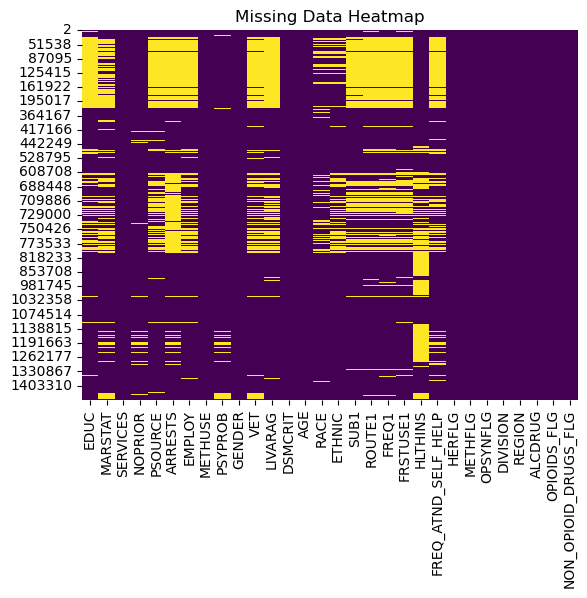

In [12]:
sns.heatmap(dsm_opioids_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

There appear to be large blocs of missing data for education, marital status, referral source, recent arrests, employment status, veteran status, living arrangement, details on primary drug of use at admission, recent attendance of substance use self-help groups, and health insurance status. All, with the exception of health insurance, appear to have the same pattern of missingness across individual patients. 

We can further explore patterns in missingness by creating a correlation matrix of missing values between variables.

<Axes: title={'center': 'Correlation of missing values between variables'}>

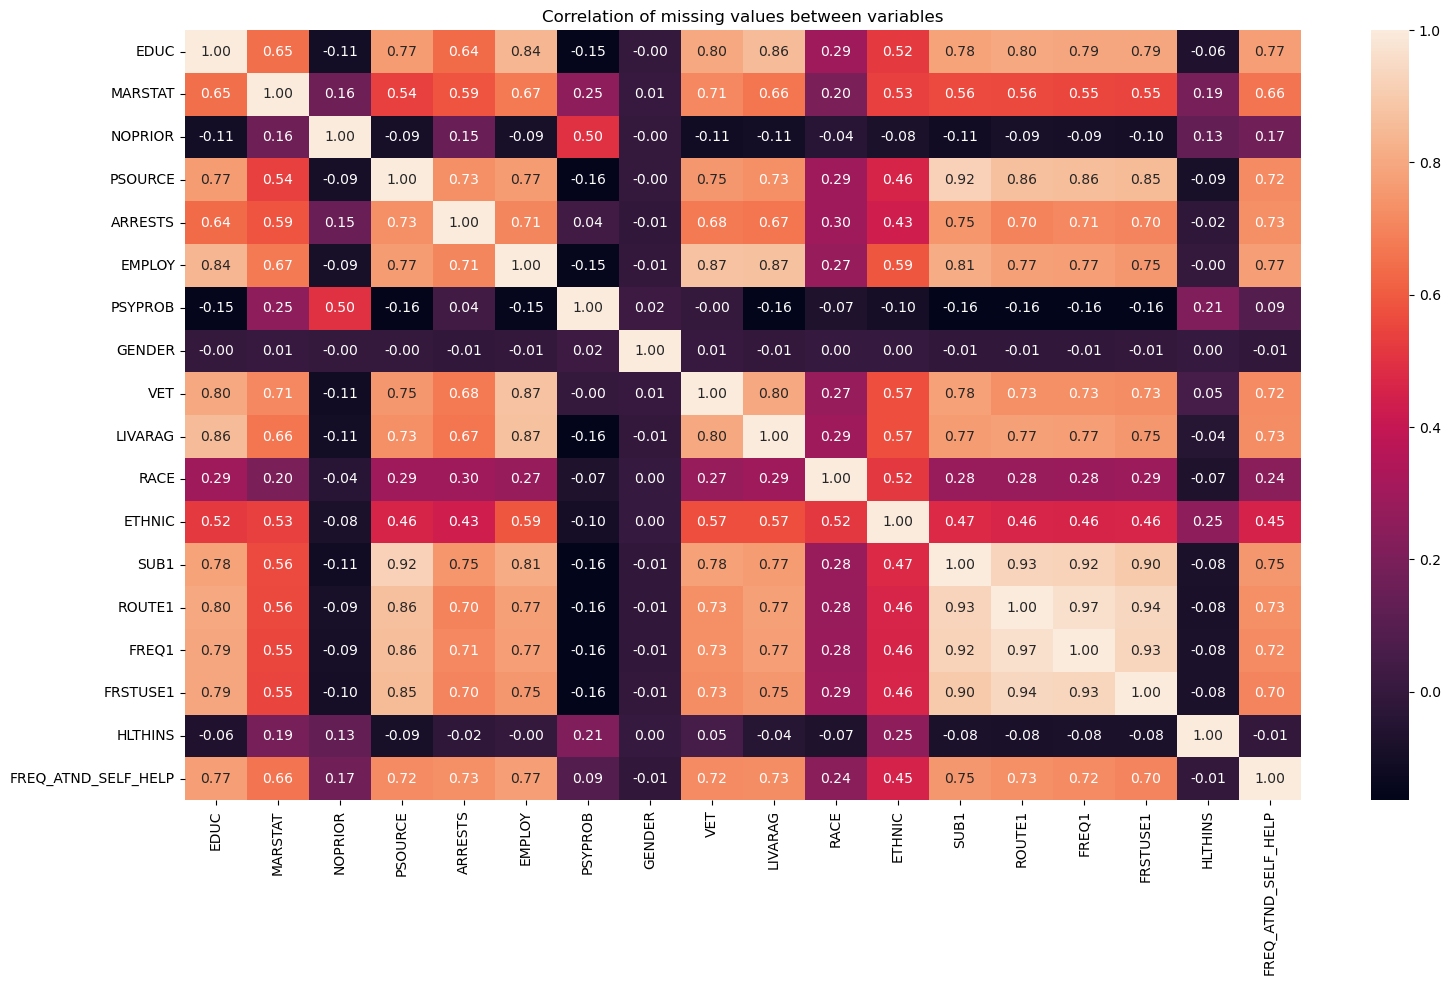

In [13]:
# using seaborn heatmap feature again
# reference: https://www.kaggle.com/code/selahattinsanli/visualizing-missing-data
plt.figure(figsize=(18,10))
plt.title('Correlation of missing values between variables')
sns.heatmap(dsm_opioids_df.loc[:, dsm_opioids_df.isnull().any()].isnull().corr(), annot=True, fmt='.2f')

This appears to be confirming the first diagram where we see that the variables mentioned above are highly correlated with each other in terms of missingness. So basically, if one of those variables was not entered for a given patient, it is highly likely that none of them were. (The exception being health insurance which doesn't seem to correlate well with missingness in any of the other variables).

This seems to imply then that only health insurance is likely to be missing completely at random. The other variables with high missingness are likely to be missing not at random. This will influence how we deal with them.

One likely reason that data is missing is that different institutions systematically do not collect this data. Let's try to look at missing values by category for `DIVISION` (to get a sense if certain States do not collect this data) and also by category for `SERVICES` (to see if different treatment service institutions do not collect this data)

In [14]:
# define a function to create a heatmap to assess missing values for variables of interest in the dataframe against the categories of a specific variable
def missing_cat_heatmap(df, miss_vars, cat_var):
    # compute percentage missing data for each column, grouped by a categorical variable
    missing_pct = df.groupby(cat_var).apply(lambda x: x[miss_vars].isnull().mean()) * 100

    # sort rows and columns for better readability
    missing_pct = missing_pct.sort_index().sort_index(axis=1)

    # plot heatmap
    plt.figure(figsize=(12,6))
    sns.heatmap(missing_pct, annot=True, fmt='.0f', cmap='viridis', cbar_kws={'label': 'Precent Missing'})
    plt.title(f'Heatmap of Missing Values by {cat_var}')
    plt.ylabel(cat_var)
    plt.xlabel('Variables')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show
 

In [15]:
# list of variables of interest based on overall high levels of missingness
# education, marital status, referral source, recent arrests, employment status, 
# veteran status, living arrangement, details on primary drug of use at admission, 
# recent attendance of substance use self-help groups, and health insurance status
miss_vars = ['EDUC', 'MARSTAT', 'PSOURCE', 'ARRESTS', 'EMPLOY', 'VET', 'LIVARAG', 'SUB1', 'ROUTE1', 'FREQ1', 'FRSTUSE1', 'FREQ_ATND_SELF_HELP', 'HLTHINS']

C:\Users\vande\AppData\Local\Temp\ipykernel_25756\3354813558.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_pct = df.groupby(cat_var).apply(lambda x: x[miss_vars].isnull().mean()) * 100


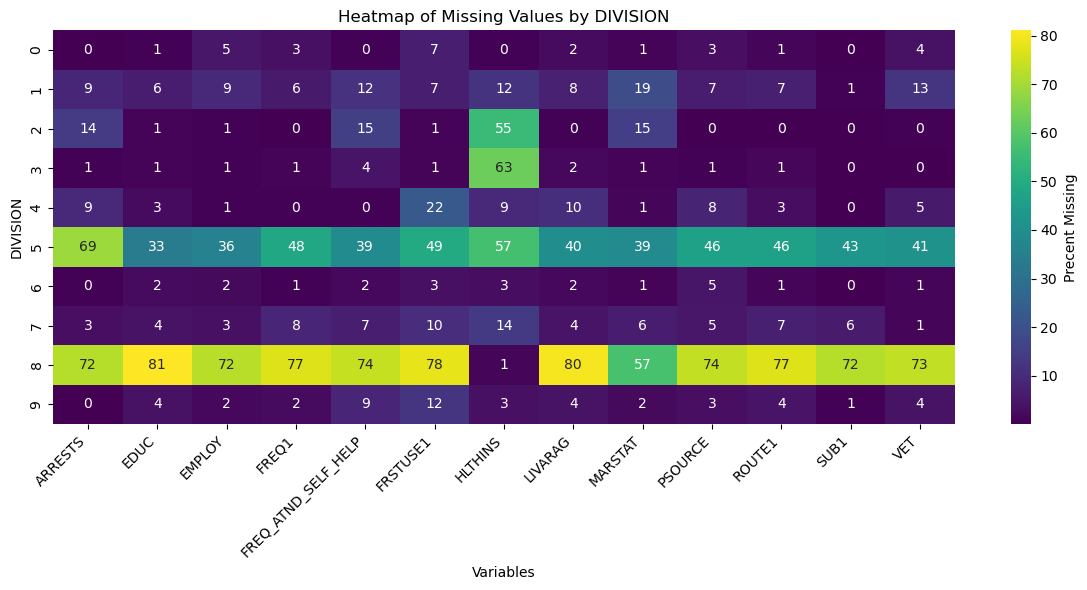

In [16]:
# use function on DIVISION
missing_cat_heatmap(dsm_opioids_df, miss_vars, 'DIVISION')

Census divisions 8 (Mountain) and 5 (South Atlantic) have high percentage of missing values for our variables of interest. Health insurance also has high missingness for divisions 2 (Middle Atlantic), 3 (East North Central) and 5.

C:\Users\vande\AppData\Local\Temp\ipykernel_25756\3354813558.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_pct = df.groupby(cat_var).apply(lambda x: x[miss_vars].isnull().mean()) * 100


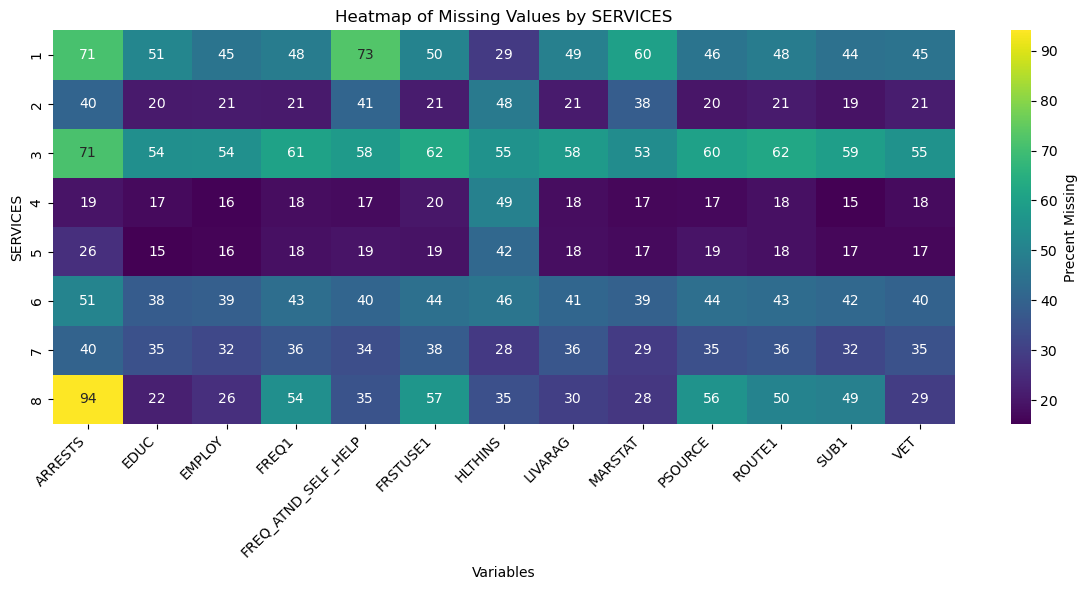

In [17]:
# use function on SERVICES
missing_cat_heatmap(dsm_opioids_df, miss_vars, 'SERVICES')

The type of service setting also seems to be associated with missingness although a bit less clearly than it was for Census division. In general it seems that clinical treatment settings are more likely to have missing data than non-clinical/residential treatment settings The service categories of hospital detox and rehab (`SERVICE`=1 and =3), as well as the ambulatory care categories (`SERVICE`=6, =7 and =8) all have generally higher percentages of missing data. 

So these appear to be what are considered "missing at random" data. Missing at random means there might be systematic differences between the missing and observed values, but these can be explained by other observed variables (see for instance: https://pmc.ncbi.nlm.nih.gov/articles/PMC4121561/). In this instance, the missing data in this set of variables is explained by geography (Census division) and type of treatment service/setting.

There are many ways to treat missing at random data ranging from simple to complex. Since our dataset is entirely categorical variables, this also limits the possibilities. 

- Two simple possibilities for catgorical data are to impute the most frequent value of the variable (mode imputation) or treat missing as its own category (i.e., fill NAs with a new 'Missing' category). 
- More complex methods include multivariate imputation (MICE). 
- Given the large number of variables with missing at random data, as well as the fact that 2 separate variables appear to be explaining this missingness, we would normally likely choose a complex method. However, we will not pursue the more complex methods here as they require more sophisticated knowledge of statistical methods which are beyond the scope of this course. 
- We will pursue instead the simple methods to see if they improve our model.

We can first check the variables in question to see if they contain categories that are clearly in the majority. If they do then we can think about imputing the most frequent value. 

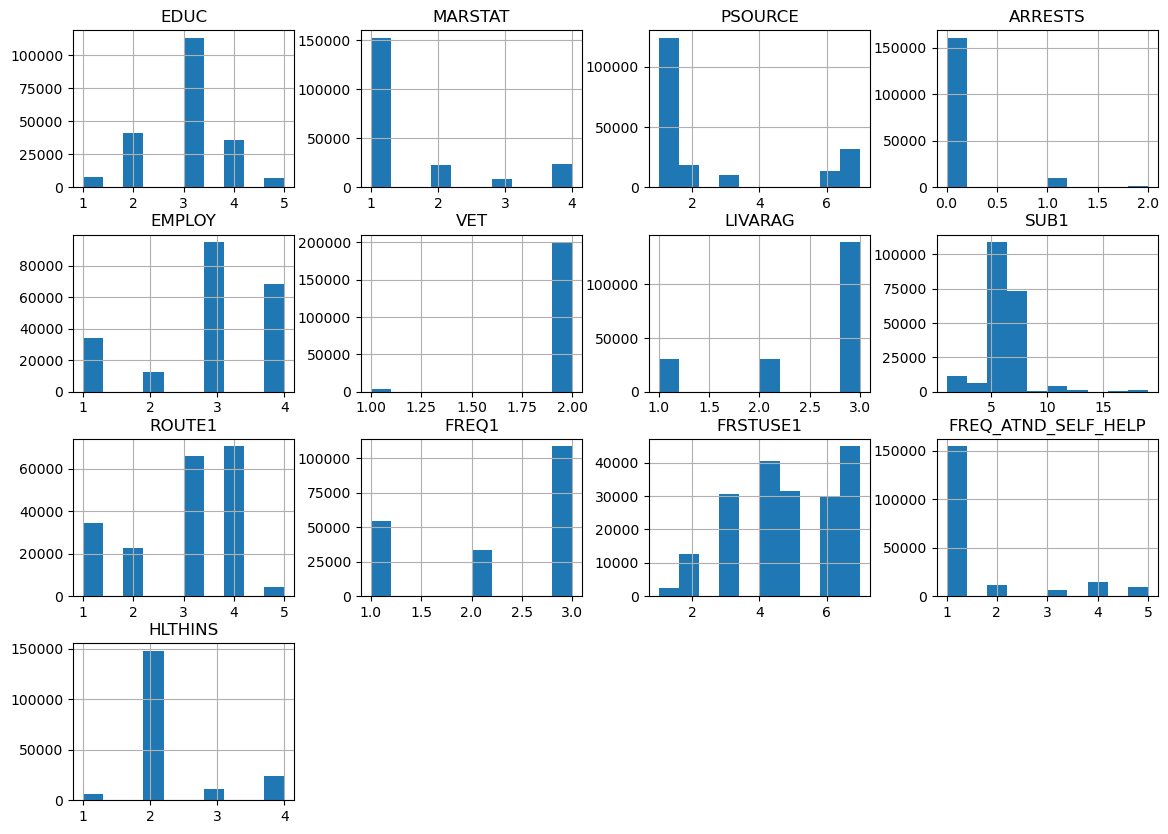

In [18]:
dsm_opioids_df[miss_vars].hist(figsize=(14,10))
plt.show()

For all of the variables in question except 3 of those involving specifics on primary substance used (`SUB1`, `ROUTE1`, `FRSTUSE1`) there is a clear majority category. We will therefore create an alternative dataset where those variables have their missing values imputed using the most frequent value.

In [19]:
# create copy dataset
dsm_opioids_df2 = dsm_opioids_df.copy()

# create vector of variables to be imputed
imputed = ['EDUC', 'MARSTAT', 'PSOURCE', 'ARRESTS', 'EMPLOY', 'VET', 'LIVARAG', 'FREQ1', 'FREQ_ATND_SELF_HELP', 'HLTHINS']

In [20]:
# use simple imputer method from scikit-learn

imputer = SimpleImputer(strategy='most_frequent')
dsm_opioids_df2[imputed] = imputer.fit_transform(dsm_opioids_df2[imputed])

dsm_opioids_df2.isnull().sum()

EDUC                         0
MARSTAT                      0
SERVICES                     0
NOPRIOR                  14991
PSOURCE                      0
ARRESTS                      0
EMPLOY                       0
METHUSE                      0
PSYPROB                  16752
GENDER                     136
VET                          0
LIVARAG                      0
DSMCRIT                      0
AGE                          0
RACE                     34690
ETHNIC                   49100
SUB1                     90187
ROUTE1                   99287
FREQ1                        0
FRSTUSE1                104336
HLTHINS                      0
FREQ_ATND_SELF_HELP          0
HERFLG                       0
METHFLG                      0
OPSYNFLG                     0
DIVISION                     0
REGION                       0
ALCDRUG                      0
OPIOIDS_FLG                  0
NON_OPIOID_DRUGS_FLG         0
dtype: int64

For the remaining 3 variables with high rates of missing data, as well as all other variables that still contain missing values, we will use the other simple technique of treating missing as its own category to be included in the modeling.

In [21]:
# create vector of variables to fill NAs with new 'Missing' category =99
mar_vars = ['SUB1', 'ROUTE1', 'FRSTUSE1', 'NOPRIOR', 'PSYPROB', 'RACE', 'ETHNIC', 'GENDER']

dsm_opioids_df2[mar_vars] = dsm_opioids_df2[mar_vars].fillna(99)

dsm_opioids_df2.isnull().sum()

EDUC                    0
MARSTAT                 0
SERVICES                0
NOPRIOR                 0
PSOURCE                 0
ARRESTS                 0
EMPLOY                  0
METHUSE                 0
PSYPROB                 0
GENDER                  0
VET                     0
LIVARAG                 0
DSMCRIT                 0
AGE                     0
RACE                    0
ETHNIC                  0
SUB1                    0
ROUTE1                  0
FREQ1                   0
FRSTUSE1                0
HLTHINS                 0
FREQ_ATND_SELF_HELP     0
HERFLG                  0
METHFLG                 0
OPSYNFLG                0
DIVISION                0
REGION                  0
ALCDRUG                 0
OPIOIDS_FLG             0
NON_OPIOID_DRUGS_FLG    0
dtype: int64

#### Comparing model with all NAs dropped vs model with imputed values

First we will run the model with all NAs dropped

In [22]:
# dataset with all NAs dropped
df_nadropped = dsm_opioids_df.dropna() 

df_nadropped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76617 entries, 2 to 1498015
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   EDUC                  76617 non-null  float64
 1   MARSTAT               76617 non-null  float64
 2   SERVICES              76617 non-null  int64  
 3   NOPRIOR               76617 non-null  float64
 4   PSOURCE               76617 non-null  float64
 5   ARRESTS               76617 non-null  float64
 6   EMPLOY                76617 non-null  float64
 7   METHUSE               76617 non-null  float64
 8   PSYPROB               76617 non-null  float64
 9   GENDER                76617 non-null  float64
 10  VET                   76617 non-null  float64
 11  LIVARAG               76617 non-null  float64
 12  DSMCRIT               76617 non-null  float64
 13  AGE                   76617 non-null  int64  
 14  RACE                  76617 non-null  float64
 15  ETHNIC                

Having removed some of the more problematic and less useful variables already helps with the sample size (76K vs around 10K). However, it still only represents about a quarter of the 296K we have for the full opioid addiction dataset.

In [23]:
#Define X and Y
#Note: Employ is being dropped as it has no variation in values, breaking the regression
nominal_used_cols = ['LIVARAG', 
                     'SERVICES',
                     'RACE',
                     'ETHNIC',
                     'MARSTAT',
                     #'SUB1',
                     'PSOURCE',
                     'EMPLOY',
                     'PSYPROB',
                     'GENDER',
                     'VET',
                     'ROUTE1',
                     'HLTHINS',
                     'FREQ_ATND_SELF_HELP',
                     'DIVISION',
                     'NON_OPIOID_DRUGS_FLG'
                    ]

ordinal_cols = ['ARRESTS', 
                'NOPRIOR',
                'AGE',
                'FRSTUSE1',
                'FREQ1',
                'PSYPROB',
                'EDUC'
               ]

y = (df_nadropped['METHUSE']==1).astype(int) #Recode to yes=1 (no change) and no=0 from no=2
X = pd.concat([df_nadropped[nominal_used_cols], df_nadropped[ordinal_cols]], axis=1) 

#Encoding of nominal/categorical variables
X = pd.get_dummies(X, columns=nominal_used_cols, drop_first=True)
# X = X.drop(columns=['SERVICES_2', 
#                     'SERVICES_4', 
#                     'SERVICES_8',
#                     'RACE_9.0',
#                     'RACE_8.0',
#                     'RACE_7.0',
#                     'RACE_5.0',
#                     'RACE_4.0',
#                     'RACE_2.0',
#                     'MARSTAT_3.0',
#                     'LIVARAG_3.0',
#                     'ETHNIC_2.0',
#                     'ETHNIC_4.0',
#                     'ETHNIC_5.0',
#                     'SUB1_3.0',
#                     'SUB1_6.0',
#                     'SUB1_7.0',
#                     'SUB1_8.0',
#                     'SUB1_9.0',
#                     'SUB1_11.0',
#                     'SUB1_12.0',
#                     'SUB1_14.0',
#                     'SUB1_16.0',
#                     'SUB1_17.0',
#                     'SUB1_18.0',
#                     'SUB1_19.0',
#                     ])
X = X.astype(int)

#Create and fit the model
#X = sm.add_constant(X) #To remove bias of intercept on predictions
model = Logit(y, X)
model = model.fit(method='newton', maxiter=500)
model.summary2()

Optimization terminated successfully.
         Current function value: 0.364043
         Iterations 7


<class 'statsmodels.iolib.summary2.Summary'>
"""
                             Results: Logit
========================================================================
Model:                 Logit              Method:             MLE       
Dependent Variable:    METHUSE            Pseudo R-squared:   0.472     
Date:                  2025-04-14 12:56   AIC:                55907.8021
No. Observations:      76617              BIC:                56481.0897
Df Model:              61                 Log-Likelihood:     -27892.   
Df Residuals:          76555              LL-Null:            -52852.   
Converged:             1.0000             LLR p-value:        0.0000    
No. Iterations:        7.0000             Scale:              1.0000    
------------------------------------------------------------------------
                         Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
------------------------------------------------------------------------
ARRESTS                 -0.0281   0.0360  -0.7820 0.4342 -0.0987  0.0424
NOPRIOR                  0.0540   0.0064   8.4220 0.0000  0.0414  0.0665
AGE                      0.0716   0.0063  11.4614 0.0000  0.0594  0.0839
FRSTUSE1                 0.0117   0.0070   1.6861 0.0918 -0.0019  0.0254
FREQ1                    0.2702   0.0136  19.7992 0.0000  0.2435  0.2970
EDUC                     0.0151   0.0133   1.1418 0.2535 -0.0108  0.0411
LIVARAG_2.0              0.0013   0.0402   0.0331 0.9736 -0.0774  0.0801
LIVARAG_3.0             -0.0746   0.0341  -2.1893 0.0286 -0.1413 -0.0078
SERVICES_2              -0.8225   0.1398  -5.8817 0.0000 -1.0965 -0.5484
SERVICES_3              -1.4161   0.1860  -7.6130 0.0000 -1.7807 -1.0515
SERVICES_4              -0.1623   0.1401  -1.1585 0.2466 -0.4368  0.1122
SERVICES_5               0.3316   0.1423   2.3310 0.0198  0.0528  0.6105
SERVICES_6               0.6764   0.1386   4.8815 0.0000  0.4048  0.9479
SERVICES_7               2.2639   0.1358  16.6757 0.0000  1.9979  2.5300
SERVICES_8               3.6446   0.2518  14.4729 0.0000  3.1511  4.1382
RACE_2.0                -5.2070   0.2287 -22.7634 0.0000 -5.6553 -4.7586
RACE_4.0                -4.7064   0.2023 -23.2593 0.0000 -5.1030 -4.3098
RACE_5.0                -4.7870   0.1985 -24.1184 0.0000 -5.1760 -4.3980
RACE_6.0                -5.1406   0.2617 -19.6455 0.0000 -5.6534 -4.6277
RACE_7.0                -4.9279   0.1925 -25.5994 0.0000 -5.3052 -4.5506
RACE_8.0                -4.3799   0.2018 -21.7074 0.0000 -4.7753 -3.9844
RACE_9.0                -5.1195   0.2887 -17.7329 0.0000 -5.6854 -4.5537
ETHNIC_2.0              -0.1030   0.0838  -1.2292 0.2190 -0.2672  0.0612
ETHNIC_3.0              -0.7044   0.0813  -8.6636 0.0000 -0.8638 -0.5451
ETHNIC_4.0              -0.3105   0.0603  -5.1527 0.0000 -0.4286 -0.1924
ETHNIC_5.0              -0.4876   0.0915  -5.3301 0.0000 -0.6669 -0.3083
MARSTAT_2.0              0.0959   0.0335   2.8630 0.0042  0.0302  0.1615
MARSTAT_3.0              0.0331   0.0514   0.6443 0.5194 -0.0676  0.1338
MARSTAT_4.0             -0.0619   0.0338  -1.8323 0.0669 -0.1281  0.0043
PSOURCE_2.0             -1.0568   0.0419 -25.2286 0.0000 -1.1389 -0.9747
PSOURCE_3.0             -0.3488   0.0493  -7.0699 0.0000 -0.4455 -0.2521
PSOURCE_4.0             -1.9856   0.2805  -7.0785 0.0000 -2.5354 -1.4358
PSOURCE_5.0              0.5283   0.2112   2.5011 0.0124  0.1143  0.9423
PSOURCE_6.0             -0.8266   0.0462 -17.8844 0.0000 -0.9172 -0.7360
PSOURCE_7.0             -1.3155   0.0307 -42.8182 0.0000 -1.3757 -1.2553
EMPLOY_2.0              -0.0329   0.0479  -0.6876 0.4917 -0.1268  0.0609
EMPLOY_3.0               0.0948   0.0299   3.1669 0.0015  0.0361  0.1534
EMPLOY_4.0               0.3596   0.0346  10.4033 0.0000  0.2919  0.4274
PSYPROB_2.0             -0.0300      nan      nan    nan     nan     nan
PSYPROB_2.0             -0.0300      nan      nan    nan     nan     nan
GENDER_2.0              -0.0412   0.0232  -1.7752 0.0759 -0.0867  0.0043
VET_2.0                 -0.2685   0.07

Now we will try running the same model with the imputed values dataset

In [24]:
y2 = (dsm_opioids_df2['METHUSE']==1).astype(int) #Recode to yes=1 (no change) and no=0 from no=2
X2 = pd.concat([dsm_opioids_df2[nominal_used_cols], dsm_opioids_df2[ordinal_cols]], axis=1) 

#Encoding of nominal/categorical variables
X2 = pd.get_dummies(X2, columns=nominal_used_cols, drop_first=True)
X2 = X2.astype(int)

In [25]:
#Create and fit the model
#X = sm.add_constant(X) #To remove bias of intercept on predictions
model2 = Logit(y2, X2)
model2 = model2.fit(method='newton', maxiter=500)
model2.summary2()

Optimization terminated successfully.
         Current function value: 0.394210
         Iterations 7


<class 'statsmodels.iolib.summary2.Summary'>
"""
                                    Results: Logit
=======================================================================================
Model:                     Logit                   Method:                  MLE        
Dependent Variable:        METHUSE                 Pseudo R-squared:        0.400      
Date:                      2025-04-14 12:56        AIC:                     234223.2695
No. Observations:          296907                  BIC:                     234944.1494
Df Model:                  67                      Log-Likelihood:          -1.1704e+05
Df Residuals:              296839                  LL-Null:                 -1.9496e+05
Converged:                 1.0000                  LLR p-value:             0.0000     
No. Iterations:            7.0000                  Scale:                   1.0000     
---------------------------------------------------------------------------------------
                         Coef.    Std.Err.      z     P>|z|      [0.025       0.975]   
---------------------------------------------------------------------------------------
ARRESTS                  0.0579          nan      nan    nan           nan          nan
NOPRIOR                 -0.0188       0.0003 -55.4769 0.0000       -0.0195      -0.0181
AGE                      0.0530       0.0026  20.4189 0.0000        0.0479       0.0581
FRSTUSE1                 0.0032       0.0004   8.5450 0.0000        0.0025       0.0040
FREQ1                    0.3101       0.0078  39.6376 0.0000        0.2948       0.3255
EDUC                    -0.0179       0.0075  -2.3985 0.0165       -0.0325      -0.0033
LIVARAG_2.0              0.0830       0.0225   3.6959 0.0002        0.0390       0.1270
LIVARAG_3.0             -0.1545       0.0176  -8.7573 0.0000       -0.1891      -0.1200
SERVICES_2               0.0289       0.0709   0.4083 0.6831       -0.1100       0.1679
SERVICES_3              -0.6626       0.1037  -6.3904 0.0000       -0.8658      -0.4594
SERVICES_4               0.1067       0.0695   1.5360 0.1245       -0.0295       0.2429
SERVICES_5               0.6449       0.0717   8.9980 0.0000        0.5044       0.7853
SERVICES_6               1.0160       0.0696  14.5867 0.0000        0.8795       1.1525
SERVICES_7               2.3199       0.0673  34.4825 0.0000        2.1881       2.4518
SERVICES_8               7.8131       0.0788  99.1211 0.0000        7.6586       7.9676
RACE_2.0                -3.9464       0.1049 -37.6170 0.0000       -4.1520      -3.7408
RACE_3.0                -3.9849       0.8663  -4.6000 0.0000       -5.6828      -2.2870
RACE_4.0                -3.7038       0.1019 -36.3379 0.0000       -3.9036      -3.5040
RACE_5.0                -3.5431       0.1077 -32.9003 0.0000       -3.7542      -3.3320
RACE_6.0                -4.1404       0.1313 -31.5370 0.0000       -4.3977      -3.8831
RACE_7.0                -4.1790       0.0890 -46.9641 0.0000       -4.3534      -4.0046
RACE_8.0                -3.1930       0.1075 -29.6930 0.0000       -3.4037      -2.9822
RACE_9.0                -3.7746       0.1482 -25.4747 0.0000       -4.0650      -3.4842
RACE_99.0               -3.7073       0.1145 -32.3747 0.0000       -3.9317      -3.4829
ETHNIC_2.0               0.1804       0.0538   3.3516 0.0008        0.0749       0.2859
ETHNIC_3.0              -0.5509       0.0471 -11.6881 0.0000       -0.6433      -0.4585
ETHNIC_4.0              -0.5212       0.0362 -14.3824 0.0000       -0.5923      -0.4502
ETHNIC_5.0              -0.4239       0.0467  -9.0698 0.0000       -0.5156      -0.3323
ETHNIC_99.0             -0.9042       0.0442 -20.4508 0.0000       -0.9909      -0.8176
MARSTAT_2.0              0.1674       0.0195   8.6065 0.0000        0.1293       0.2055
MARSTAT_3.0              0.1907       0.0301   6.3396 0.0000        0.1317       0.2496
MARSTAT_4.0              0.1098       0.0194   5.6530 0.0000        0.0717       0.1478
PSOURCE_2.0             -0.6

It seems that this method did not improve the model based on pseudo R-squared: 0.400 vs 0.472 in the model with all NA removed. 

It might then be worthwhile to just drop all NAs as originally planned but be more strategic about which variables we keep in the model. Already having pared it down to a more useful selection has improved the score from the original model (Pseudo R-square of 0.25).

It would also likely be helpful to do some feature engineering of the X variables to create more logical categories. This will reduce the number of features overall in the model which will likely improve the fit while also being more intuitive to explain the results. 

Here are some proposed new categories for select variables:
- `AGE`: 12-20 years (1-3); 21-29 years (4-5); 31-39 years (6-7); 40-49 years (8-9); 50+ years (10-12)
- `RACE`: Indigenous/Islander (1-3, 9); Black; White; Asian; Other (7-9)
- `ETHNIC`: Latino (1, 2, 3, 5); Not Latino (5)
- `EDUC`: Less than high school (1, 2); High school (3); Post-Secondary (4, 5)
- `LIVARAG`: Homeless (1); Not homeless (2, 3)
- `ARRESTS`: None past 30 days (0); One or more past 30 days (1, 2)
- `SERVICES`: Detox (1, 2); Rehab (3-5); Ambulatory care (6-8)
- `PSOURCE`: Individual (1); Care provider (2, 3); School/work/community (4-6); Court (7)
- `NOPRIOR`: 0 prior treatment (0); 1 (1); 2 or more (2-5)
- `FRSTUSE1`: 11-17 years; 18-24; 25 and older
- `HLTHINS`: Private (1); Medicaid (2, 3); None (4) 
- `FREQ_ATND_SELF_HELP`: None past month (1); 1 or more times past month(2-5)






---------------------------------
## DATA RECLASSIFICATION/RECATEGORIZATION

The above changes will be made and we will reassess the distribution of patients in these new categories (which may lead to reassessment of missing data treatment).

In [26]:
dsm_opioids_df3 = dsm_opioids_df.copy()



In [27]:
# re-categorize age groups
# `AGE`: 12-20 years (1-3); 21-29 years (4-5); 31-39 years (6-7); 40-49 years (8-9); 50+ years (10-12)

age_dict = {
    1: '12_20',
    2: '12_20',
    3: '12_20',
    4: '21_29',
    5: '21_29',
    6: '30_39',
    7: '30_39',
    8: '40_49',
    9: '40_49',
    10: '50+',
    11: '50+',
    12: '50+'
}

dsm_opioids_df3['AGE'] = dsm_opioids_df3['AGE'].map(age_dict)

dsm_opioids_df3['AGE'].value_counts().sort_index()


AGE
12_20      4930
21_29     60405
30_39    117895
40_49     60061
50+       53616
Name: count, dtype: int64

In [28]:
# re-categorize age groups #attempted run, but problems arose, so a different methodology was employed
# `AGE`: 12-20 years (1-3); 21-29 years (4-5); 31-39 years (6-7); 40-49 years (8-9); 50+ years (10-12)
# age_bins = [1, 4, 6, 8, 10, 13]
# age_labs = ['12-20 yrs', '21-29 yrs', '30-39 yrs', '40-49 yrs', '50+ yrs']

# dsm_opioids_df3['age_new'] = pd.cut(dsm_opioids_df3['AGE'], age_bins, right=False, labels=age_labs)

# pd.crosstab(dsm_opioids_df3['METHUSE'], dsm_opioids_df3['age_new'])

In [29]:
# create dummy variables for analysis: age
dummy_age = pd.get_dummies(dsm_opioids_df3['AGE'], prefix='age').astype(np.uint8)
dsm_opioids_df3 = dsm_opioids_df3.join(dummy_age)

dsm_opioids_df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296907 entries, 2 to 1498032
Data columns (total 35 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   EDUC                  206163 non-null  float64
 1   MARSTAT               207767 non-null  float64
 2   SERVICES              296907 non-null  int64  
 3   NOPRIOR               281916 non-null  float64
 4   PSOURCE               199446 non-null  float64
 5   ARRESTS               172657 non-null  float64
 6   EMPLOY                209978 non-null  float64
 7   METHUSE               296907 non-null  float64
 8   PSYPROB               280155 non-null  float64
 9   GENDER                296771 non-null  float64
 10  VET                   203773 non-null  float64
 11  LIVARAG               200603 non-null  float64
 12  DSMCRIT               296907 non-null  float64
 13  AGE                   296907 non-null  object 
 14  RACE                  262217 non-null  float64
 15  ETHN

In [30]:
# check if can run a regression on age using bins and cut
# dummy_age = pd.get_dummies(dsm_opioids_df3['age_new']).astype(np.uint8)
# dsm_opioids_df3 = dsm_opioids_df3.join(dummy_age)

# dsm_opioids_df3.info()

In [31]:
y = (dsm_opioids_df3['METHUSE']==1).astype(int) #Recode to yes=1 (no change) and no=0 from no=2


In [32]:
# Fit the model
X_age = ['age_12_20', 'age_21_29', 'age_30_39', 'age_40_49', 'age_50+']
m_age = Logit(y, dsm_opioids_df3[X_age]).fit()


Optimization terminated successfully.
         Current function value: 0.652507
         Iterations 5


In [33]:
m_age.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                          Results: Logit
==================================================================
Model:              Logit            Method:           MLE        
Dependent Variable: METHUSE          Pseudo R-squared: 0.006      
Date:               2025-04-14 12:56 AIC:              387477.6072
No. Observations:   296907           BIC:              387530.6131
Df Model:           4                Log-Likelihood:   -1.9373e+05
Df Residuals:       296902           LL-Null:          -1.9496e+05
Converged:          1.0000           LLR p-value:      0.0000     
No. Iterations:     5.0000           Scale:            1.0000     
-------------------------------------------------------------------
               Coef.   Std.Err.     z      P>|z|    [0.025   0.975]
-------------------------------------------------------------------
age_12_20     -1.4978    0.0369  -40.6427  0.0000  -1.5700  -1.4255
age_21_29     -0.8170    0.0088  -92.5684  0.0000  -0.8343  -0.7997
age_30_39     -0.5415    0.0060  -89.6655  0.0000  -0.5534  -0.5297
age_40_49     -0.4310    0.0084  -51.6125  0.0000  -0.4474  -0.4147
age_50+       -0.3511    0.0088  -40.0271  0.0000  -0.3683  -0.3339
==================================================================

"""

Model can be fit with the category type variables so we will continue to re-categorize using this approach

In [34]:
# race distribution
dsm_opioids_df3['RACE'].value_counts().sort_index()

RACE
1.0       279
2.0      5103
3.0        25
4.0     46780
5.0    193177
6.0      1358
7.0     11965
8.0      2850
9.0       680
Name: count, dtype: int64

In [35]:
# re-categorize race categories
# `RACE`: Indigenous/Islander (1-3, 9); Black; White; Asian; Other (7-9)

race_dict = {
    1: 'indig_island',
    2: 'indig_island',
    3: 'indig_island',
    4: 'black',
    5: 'white',
    6: 'asian',
    7: 'other',
    8: 'other',
    9: 'indig_island'
}

dsm_opioids_df3['RACE'] = dsm_opioids_df3['RACE'].map(race_dict)

dsm_opioids_df3['RACE'].value_counts()


RACE
white           193177
black            46780
other            14815
indig_island      6087
asian             1358
Name: count, dtype: int64

In [36]:
# create dummy variables for analysis: race
dummy_race = pd.get_dummies(dsm_opioids_df3['RACE'], prefix='race').astype(np.uint8)
dsm_opioids_df3 = dsm_opioids_df3.join(dummy_race)

dsm_opioids_df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296907 entries, 2 to 1498032
Data columns (total 40 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   EDUC                  206163 non-null  float64
 1   MARSTAT               207767 non-null  float64
 2   SERVICES              296907 non-null  int64  
 3   NOPRIOR               281916 non-null  float64
 4   PSOURCE               199446 non-null  float64
 5   ARRESTS               172657 non-null  float64
 6   EMPLOY                209978 non-null  float64
 7   METHUSE               296907 non-null  float64
 8   PSYPROB               280155 non-null  float64
 9   GENDER                296771 non-null  float64
 10  VET                   203773 non-null  float64
 11  LIVARAG               200603 non-null  float64
 12  DSMCRIT               296907 non-null  float64
 13  AGE                   296907 non-null  object 
 14  RACE                  262217 non-null  object 
 15  ETHN

In [37]:
# ethnicity distribution 
dsm_opioids_df3['ETHNIC'].value_counts().sort_index()

ETHNIC
1.0     10499
2.0      3459
3.0      5678
4.0    221069
5.0      7102
Name: count, dtype: int64

In [38]:
# re-categorize ethnicity categories (basically details on type of Latino population so we can consolidate this into Latino/Not Latino)
# `ETHNIC`: Latino (1, 2, 3, 5); Not Latino (4)

ethnic_dict = {
    1: 'latino',
    2: 'latino',
    3: 'latino',
    4: 'non-latino',
    5: 'latino'
}

dsm_opioids_df3['ETHNIC'] = dsm_opioids_df3['ETHNIC'].map(ethnic_dict)

dsm_opioids_df3['ETHNIC'].value_counts()


ETHNIC
non-latino    221069
latino         26738
Name: count, dtype: int64

In [39]:
# create dummy variables for analysis: ethnicity
dummy_ethnic = pd.get_dummies(dsm_opioids_df3['ETHNIC'], prefix='ethnic').astype(np.uint8)
dsm_opioids_df3 = dsm_opioids_df3.join(dummy_ethnic)

dsm_opioids_df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296907 entries, 2 to 1498032
Data columns (total 42 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   EDUC                  206163 non-null  float64
 1   MARSTAT               207767 non-null  float64
 2   SERVICES              296907 non-null  int64  
 3   NOPRIOR               281916 non-null  float64
 4   PSOURCE               199446 non-null  float64
 5   ARRESTS               172657 non-null  float64
 6   EMPLOY                209978 non-null  float64
 7   METHUSE               296907 non-null  float64
 8   PSYPROB               280155 non-null  float64
 9   GENDER                296771 non-null  float64
 10  VET                   203773 non-null  float64
 11  LIVARAG               200603 non-null  float64
 12  DSMCRIT               296907 non-null  float64
 13  AGE                   296907 non-null  object 
 14  RACE                  262217 non-null  object 
 15  ETHN

In [40]:
# education distribution 
dsm_opioids_df3['EDUC'].value_counts().sort_index()

EDUC
1.0      8058
2.0     41472
3.0    113355
4.0     35873
5.0      7405
Name: count, dtype: int64

In [41]:
# re-categorize education categories (focus on high school completion and any post-secondary education)
# `EDUC`: Less than high school (1, 2); High school (3); Post-Secondary (4, 5)

educ_dict = {
    1: 'lt_high_sch',
    2: 'lt_high_sch',
    3: 'high_school',
    4: 'post_sec',
    5: 'post_sec'
}

dsm_opioids_df3['EDUC'] = dsm_opioids_df3['EDUC'].map(educ_dict)

dsm_opioids_df3['EDUC'].value_counts()


EDUC
high_school    113355
lt_high_sch     49530
post_sec        43278
Name: count, dtype: int64

In [42]:
# create dummy variables for analysis: education
dummy_educ = pd.get_dummies(dsm_opioids_df3['EDUC'], prefix='educ').astype(np.uint8)
dsm_opioids_df3 = dsm_opioids_df3.join(dummy_educ)

dsm_opioids_df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296907 entries, 2 to 1498032
Data columns (total 45 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   EDUC                  206163 non-null  object 
 1   MARSTAT               207767 non-null  float64
 2   SERVICES              296907 non-null  int64  
 3   NOPRIOR               281916 non-null  float64
 4   PSOURCE               199446 non-null  float64
 5   ARRESTS               172657 non-null  float64
 6   EMPLOY                209978 non-null  float64
 7   METHUSE               296907 non-null  float64
 8   PSYPROB               280155 non-null  float64
 9   GENDER                296771 non-null  float64
 10  VET                   203773 non-null  float64
 11  LIVARAG               200603 non-null  float64
 12  DSMCRIT               296907 non-null  float64
 13  AGE                   296907 non-null  object 
 14  RACE                  262217 non-null  object 
 15  ETHN

In [43]:
# living arrangement distribution 
dsm_opioids_df3['LIVARAG'].value_counts().sort_index()

LIVARAG
1.0     30556
2.0     30614
3.0    139433
Name: count, dtype: int64

In [44]:
# re-categorize living arrangement categories (focus on whether or not homeless)
# `LIVARAG`: Homeless (1); Not homeless (2, 3)

livarag_dict = {
    1: 'homeless',
    2: 'not_homeless',
    3: 'not_homeless'
}

dsm_opioids_df3['LIVARAG'] = dsm_opioids_df3['LIVARAG'].map(livarag_dict)

dsm_opioids_df3['LIVARAG'].value_counts()


LIVARAG
not_homeless    170047
homeless         30556
Name: count, dtype: int64

In [45]:
# create dummy variables for analysis: living arrangement
dummy_livarag = pd.get_dummies(dsm_opioids_df3['LIVARAG'], prefix='livarag').astype(np.uint8)
dsm_opioids_df3 = dsm_opioids_df3.join(dummy_livarag)

dsm_opioids_df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296907 entries, 2 to 1498032
Data columns (total 47 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   EDUC                  206163 non-null  object 
 1   MARSTAT               207767 non-null  float64
 2   SERVICES              296907 non-null  int64  
 3   NOPRIOR               281916 non-null  float64
 4   PSOURCE               199446 non-null  float64
 5   ARRESTS               172657 non-null  float64
 6   EMPLOY                209978 non-null  float64
 7   METHUSE               296907 non-null  float64
 8   PSYPROB               280155 non-null  float64
 9   GENDER                296771 non-null  float64
 10  VET                   203773 non-null  float64
 11  LIVARAG               200603 non-null  object 
 12  DSMCRIT               296907 non-null  float64
 13  AGE                   296907 non-null  object 
 14  RACE                  262217 non-null  object 
 15  ETHN

In [46]:
# recent arrest distribution 
dsm_opioids_df3['ARRESTS'].value_counts().sort_index()


ARRESTS
0.0    160627
1.0     10130
2.0      1900
Name: count, dtype: int64

In [47]:
# re-categorize arrests in past 30 days(yes or no)
# `ARRESTS`: None past 30 days (0); One or more past 30 days (1, 2)

arrests_dict = {
    0: 'none',
    1: '1+',
    2: '1+'
}

dsm_opioids_df3['ARRESTS'] = dsm_opioids_df3['ARRESTS'].map(arrests_dict)

dsm_opioids_df3['ARRESTS'].value_counts()


ARRESTS
none    160627
1+       12030
Name: count, dtype: int64

In [48]:
# create dummy variables for analysis: arrests
dummy_arrests = pd.get_dummies(dsm_opioids_df3['ARRESTS'], prefix='arrests').astype(np.uint8)
dsm_opioids_df3 = dsm_opioids_df3.join(dummy_arrests)

dsm_opioids_df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296907 entries, 2 to 1498032
Data columns (total 49 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   EDUC                  206163 non-null  object 
 1   MARSTAT               207767 non-null  float64
 2   SERVICES              296907 non-null  int64  
 3   NOPRIOR               281916 non-null  float64
 4   PSOURCE               199446 non-null  float64
 5   ARRESTS               172657 non-null  object 
 6   EMPLOY                209978 non-null  float64
 7   METHUSE               296907 non-null  float64
 8   PSYPROB               280155 non-null  float64
 9   GENDER                296771 non-null  float64
 10  VET                   203773 non-null  float64
 11  LIVARAG               200603 non-null  object 
 12  DSMCRIT               296907 non-null  float64
 13  AGE                   296907 non-null  object 
 14  RACE                  262217 non-null  object 
 15  ETHN

In [49]:
# treatment type distribution 
dsm_opioids_df3['SERVICES'].value_counts().sort_index()


SERVICES
1      2631
2     36918
3      4076
4     26930
5     14581
6     31980
7    165571
8     14220
Name: count, dtype: int64

In [50]:
# re-categorize treatment type
# `SERVICES`: Detox (1, 2); Rehab (3-5); Ambulatory care (6-8)

services_dict = {
    1: 'detox',
    2: 'detox',
    3: 'rehab',
    4: 'rehab',
    5: 'rehab',
    6: 'ambulatory',
    7: 'ambulatory',
    8: 'ambulatory'
}

dsm_opioids_df3['SERVICES'] = dsm_opioids_df3['SERVICES'].map(services_dict)

dsm_opioids_df3['SERVICES'].value_counts()


SERVICES
ambulatory    211771
rehab          45587
detox          39549
Name: count, dtype: int64

In [51]:
# create dummy variables for analysis: services
dummy_services = pd.get_dummies(dsm_opioids_df3['SERVICES'], prefix='services').astype(np.uint8)
dsm_opioids_df3 = dsm_opioids_df3.join(dummy_services)

dsm_opioids_df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296907 entries, 2 to 1498032
Data columns (total 52 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   EDUC                  206163 non-null  object 
 1   MARSTAT               207767 non-null  float64
 2   SERVICES              296907 non-null  object 
 3   NOPRIOR               281916 non-null  float64
 4   PSOURCE               199446 non-null  float64
 5   ARRESTS               172657 non-null  object 
 6   EMPLOY                209978 non-null  float64
 7   METHUSE               296907 non-null  float64
 8   PSYPROB               280155 non-null  float64
 9   GENDER                296771 non-null  float64
 10  VET                   203773 non-null  float64
 11  LIVARAG               200603 non-null  object 
 12  DSMCRIT               296907 non-null  float64
 13  AGE                   296907 non-null  object 
 14  RACE                  262217 non-null  object 
 15  ETHN

In [52]:
# referral source distribution 
dsm_opioids_df3['PSOURCE'].value_counts().sort_index()

PSOURCE
1.0    124195
2.0     18618
3.0     10344
4.0       220
5.0       722
6.0     13489
7.0     31858
Name: count, dtype: int64

In [53]:
# re-categorize referral source
# `PSOURCE`: Individual (1); Care provider (2, 3); School/work/community (4-6); Court (7)

psource_dict = {
    1: 'individual',
    2: 'care_provider',
    3: 'care_provider',
    4: 'sch_work_comm',
    5: 'sch_work_comm',
    6: 'sch_work_comm',
    7: 'court'
}

dsm_opioids_df3['PSOURCE'] = dsm_opioids_df3['PSOURCE'].map(psource_dict)

dsm_opioids_df3['PSOURCE'].value_counts()


PSOURCE
individual       124195
court             31858
care_provider     28962
sch_work_comm     14431
Name: count, dtype: int64

In [54]:
# create dummy variables for analysis: referral source
dummy_psource = pd.get_dummies(dsm_opioids_df3['PSOURCE'], prefix='psource').astype(np.uint8)
dsm_opioids_df3 = dsm_opioids_df3.join(dummy_psource)

dsm_opioids_df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296907 entries, 2 to 1498032
Data columns (total 56 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   EDUC                   206163 non-null  object 
 1   MARSTAT                207767 non-null  float64
 2   SERVICES               296907 non-null  object 
 3   NOPRIOR                281916 non-null  float64
 4   PSOURCE                199446 non-null  object 
 5   ARRESTS                172657 non-null  object 
 6   EMPLOY                 209978 non-null  float64
 7   METHUSE                296907 non-null  float64
 8   PSYPROB                280155 non-null  float64
 9   GENDER                 296771 non-null  float64
 10  VET                    203773 non-null  float64
 11  LIVARAG                200603 non-null  object 
 12  DSMCRIT                296907 non-null  float64
 13  AGE                    296907 non-null  object 
 14  RACE                   262217 non-null  

In [55]:
# prior treatment distribution 
dsm_opioids_df3['NOPRIOR'].value_counts().sort_index()


NOPRIOR
0.0    62753
1.0    64389
2.0    47152
3.0    29609
4.0    20178
5.0    57835
Name: count, dtype: int64

In [56]:
# re-categorize prior treatment
# `NOPRIOR`: 0 prior treatment (0); 1 (1); 2 or more (2-5)

noprior_dict = {
    0: 'none',
    1: 'one',
    2: '2+',
    3: '2+',
    4: '2+',
    5: '2+'
}

dsm_opioids_df3['NOPRIOR'] = dsm_opioids_df3['NOPRIOR'].map(noprior_dict)

dsm_opioids_df3['NOPRIOR'].value_counts()


NOPRIOR
2+      154774
one      64389
none     62753
Name: count, dtype: int64

In [57]:
# create dummy variables for analysis: referral source
dummy_noprior = pd.get_dummies(dsm_opioids_df3['NOPRIOR'], prefix='noprior').astype(np.uint8)
dsm_opioids_df3 = dsm_opioids_df3.join(dummy_noprior)

dsm_opioids_df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296907 entries, 2 to 1498032
Data columns (total 59 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   EDUC                   206163 non-null  object 
 1   MARSTAT                207767 non-null  float64
 2   SERVICES               296907 non-null  object 
 3   NOPRIOR                281916 non-null  object 
 4   PSOURCE                199446 non-null  object 
 5   ARRESTS                172657 non-null  object 
 6   EMPLOY                 209978 non-null  float64
 7   METHUSE                296907 non-null  float64
 8   PSYPROB                280155 non-null  float64
 9   GENDER                 296771 non-null  float64
 10  VET                    203773 non-null  float64
 11  LIVARAG                200603 non-null  object 
 12  DSMCRIT                296907 non-null  float64
 13  AGE                    296907 non-null  object 
 14  RACE                   262217 non-null  

In [58]:
# first use of primary drug distribution 
dsm_opioids_df3['FRSTUSE1'].value_counts().sort_index()


FRSTUSE1
1.0     2287
2.0    12574
3.0    30762
4.0    40452
5.0    31580
6.0    29955
7.0    44961
Name: count, dtype: int64

In [59]:
# re-categorize first use of primary drug
# `FRSTUSE1`: 11-17 years; 18-24; 25 and older

frstuse1_dict = {
    1: '11_17',
    2: '11_17',
    3: '11_17',
    4: '18_24',
    5: '18_24',
    6: '25+',
    7: '25+'
}

dsm_opioids_df3['FRSTUSE1'] = dsm_opioids_df3['FRSTUSE1'].map(frstuse1_dict)

dsm_opioids_df3['FRSTUSE1'].value_counts()


FRSTUSE1
25+      74916
18_24    72032
11_17    45623
Name: count, dtype: int64

In [60]:
# create dummy variables for analysis: first use primary
dummy_frstuse1 = pd.get_dummies(dsm_opioids_df3['FRSTUSE1'], prefix='frstuse1').astype(np.uint8)
dsm_opioids_df3 = dsm_opioids_df3.join(dummy_frstuse1)

dsm_opioids_df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296907 entries, 2 to 1498032
Data columns (total 62 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   EDUC                   206163 non-null  object 
 1   MARSTAT                207767 non-null  float64
 2   SERVICES               296907 non-null  object 
 3   NOPRIOR                281916 non-null  object 
 4   PSOURCE                199446 non-null  object 
 5   ARRESTS                172657 non-null  object 
 6   EMPLOY                 209978 non-null  float64
 7   METHUSE                296907 non-null  float64
 8   PSYPROB                280155 non-null  float64
 9   GENDER                 296771 non-null  float64
 10  VET                    203773 non-null  float64
 11  LIVARAG                200603 non-null  object 
 12  DSMCRIT                296907 non-null  float64
 13  AGE                    296907 non-null  object 
 14  RACE                   262217 non-null  

In [61]:
# health insurance distribution 
dsm_opioids_df3['HLTHINS'].value_counts().sort_index()


HLTHINS
1.0      6222
2.0    148177
3.0     11596
4.0     24461
Name: count, dtype: int64

In [62]:
# re-categorize health insurance
# `HLTHINS`: Private (1); Medicaid (2, 3); None (4)

hlthins_dict = {
    1: 'private',
    2: 'medicaid',
    3: 'medicaid',
    4: 'none'
}

dsm_opioids_df3['HLTHINS'] = dsm_opioids_df3['HLTHINS'].map(hlthins_dict)

dsm_opioids_df3['HLTHINS'].value_counts()


HLTHINS
medicaid    159773
none         24461
private       6222
Name: count, dtype: int64

In [63]:

# create dummy variables for analysis: health insurance
dummy_hlthins = pd.get_dummies(dsm_opioids_df3['HLTHINS'], prefix='hlthins').astype(np.uint8)
dsm_opioids_df3 = dsm_opioids_df3.join(dummy_hlthins)

dsm_opioids_df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296907 entries, 2 to 1498032
Data columns (total 65 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   EDUC                   206163 non-null  object 
 1   MARSTAT                207767 non-null  float64
 2   SERVICES               296907 non-null  object 
 3   NOPRIOR                281916 non-null  object 
 4   PSOURCE                199446 non-null  object 
 5   ARRESTS                172657 non-null  object 
 6   EMPLOY                 209978 non-null  float64
 7   METHUSE                296907 non-null  float64
 8   PSYPROB                280155 non-null  float64
 9   GENDER                 296771 non-null  float64
 10  VET                    203773 non-null  float64
 11  LIVARAG                200603 non-null  object 
 12  DSMCRIT                296907 non-null  float64
 13  AGE                    296907 non-null  object 
 14  RACE                   262217 non-null  

In [64]:
# recent self-help group distribution 
dsm_opioids_df3['FREQ_ATND_SELF_HELP'].value_counts().sort_index()

FREQ_ATND_SELF_HELP
1.0    154735
2.0     11061
3.0      6334
4.0     14919
5.0      8961
Name: count, dtype: int64

In [65]:
# re-categorize recent self-help group
# `FREQ_ATND_SELF_HELP`: None past month (1); 1 or more times past month(2-5)

self_help_dict = {
    1: 'none',
    2: '1+',
    3: '1+',
    4: '1+',
    5: '1+'
}

dsm_opioids_df3['FREQ_ATND_SELF_HELP'] = dsm_opioids_df3['FREQ_ATND_SELF_HELP'].map(self_help_dict)

dsm_opioids_df3['FREQ_ATND_SELF_HELP'].value_counts()


FREQ_ATND_SELF_HELP
none    154735
1+       41275
Name: count, dtype: int64

In [66]:
# create dummy variables for analysis: recent self-help group
dummy_self_help = pd.get_dummies(dsm_opioids_df3['FREQ_ATND_SELF_HELP'], prefix='self_help').astype(np.uint8)
dsm_opioids_df3 = dsm_opioids_df3.join(dummy_self_help)

dsm_opioids_df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296907 entries, 2 to 1498032
Data columns (total 67 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   EDUC                   206163 non-null  object 
 1   MARSTAT                207767 non-null  float64
 2   SERVICES               296907 non-null  object 
 3   NOPRIOR                281916 non-null  object 
 4   PSOURCE                199446 non-null  object 
 5   ARRESTS                172657 non-null  object 
 6   EMPLOY                 209978 non-null  float64
 7   METHUSE                296907 non-null  float64
 8   PSYPROB                280155 non-null  float64
 9   GENDER                 296771 non-null  float64
 10  VET                    203773 non-null  float64
 11  LIVARAG                200603 non-null  object 
 12  DSMCRIT                296907 non-null  float64
 13  AGE                    296907 non-null  object 
 14  RACE                   262217 non-null  

In [67]:
# renaming divisions group

divisions_dict = {
    0: "us_territories", #(e.g., Puerto Rico)
    1: "new_england", #(Connecticut, Maine, Massachusetts, New Hampshire, Rhode Island, Vermont)
    2: "middle_atlantic", #(New Jersey, New York, Pennsylvania)
    3: "east_north_central", #(Illinois, Indiana, Michigan, Ohio, Wisconsin)
    4: "west_north_central", #(Iowa, Kansas, Minnesota, Missouri, Nebraska, North Dakota, South Dakota)
    5: "south_atlantic", #(Delaware, District of Columbia, Florida, Georgia, Maryland, North Carolina, South Carolina, Virginia, West Virginia)
    6: "east_south_central", #(Alabama, Kentucky, Mississippi, Tennessee)
    7: "west_south_central", #(Arkansas, Louisiana, Oklahoma, Texas)
    8: "mountain", #(Arizona, Colorado, Idaho, Montana, Nevada, New Mexico, Utah, Wyoming)
    9: "pacific", #(Alaska, California, Hawaii, Oregon, Washington)
}

dsm_opioids_df3['DIVISION'] = dsm_opioids_df3['DIVISION'].map(divisions_dict)

dsm_opioids_df3['DIVISION'].value_counts()


DIVISION
south_atlantic        89793
mountain              71174
middle_atlantic       55963
east_north_central    30905
new_england           25178
east_south_central    12868
west_south_central     4389
west_north_central     4225
us_territories         1274
pacific                1138
Name: count, dtype: int64

In [68]:
# create dummy variables for analysis: division group
dummy_division = pd.get_dummies(dsm_opioids_df3['DIVISION'], prefix='division').astype(np.uint8)
dsm_opioids_df3 = dsm_opioids_df3.join(dummy_division)

dsm_opioids_df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296907 entries, 2 to 1498032
Data columns (total 77 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   EDUC                         206163 non-null  object 
 1   MARSTAT                      207767 non-null  float64
 2   SERVICES                     296907 non-null  object 
 3   NOPRIOR                      281916 non-null  object 
 4   PSOURCE                      199446 non-null  object 
 5   ARRESTS                      172657 non-null  object 
 6   EMPLOY                       209978 non-null  float64
 7   METHUSE                      296907 non-null  float64
 8   PSYPROB                      280155 non-null  float64
 9   GENDER                       296771 non-null  float64
 10  VET                          203773 non-null  float64
 11  LIVARAG                      200603 non-null  object 
 12  DSMCRIT                      296907 non-null  float64
 13  AGE

------------------------------------
## SECONDARY EXPLORATION OF REFINED DATASET: GRAPHING VARIABLES OF INTEREST


The following elements are cited in the academic literature as key determinants of initiating methdadone/buprenorphine for opioid use disorder (with relevant variable name(s) in brackets)
- Race and ethnicity (RACE, ETHNIC)
- Income and insurance status (HLTHINS)
- Housing status (LIVARAG)
- Potency of opioid used (a proxy is route of administration: ROUTE1)
- Duration and severity of use (FRSTUSE1, FREQ1)
- History of treatment adherence (FREQ_ATND_SELF_HELP)
- Lack of knowledge or misconceptions about treatment (a proxy could be education: EDUC)
- Geographic location (DIVISION)
- Psychosocial stability/mental health

We will visualize differences for the variables mentioned above on treatment status outcome. We will also add age group and gender as these will be important potential modifying factors in the model.


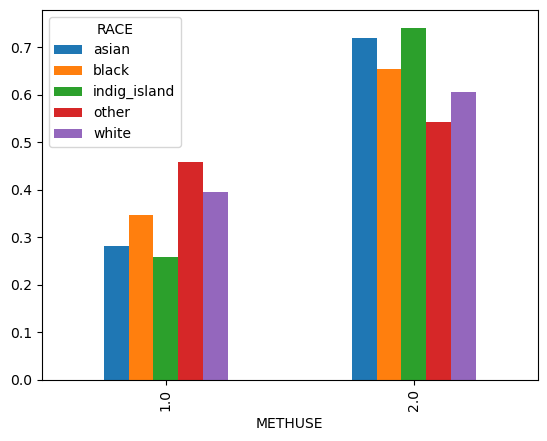

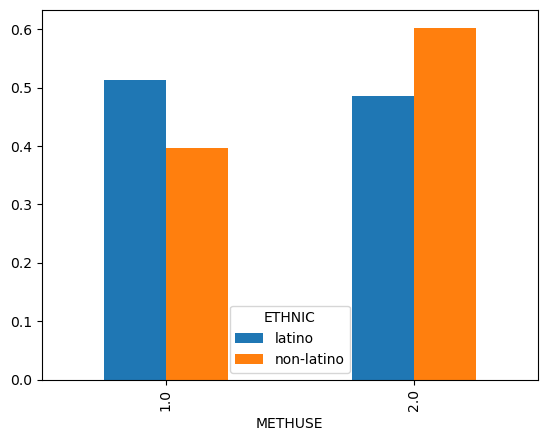

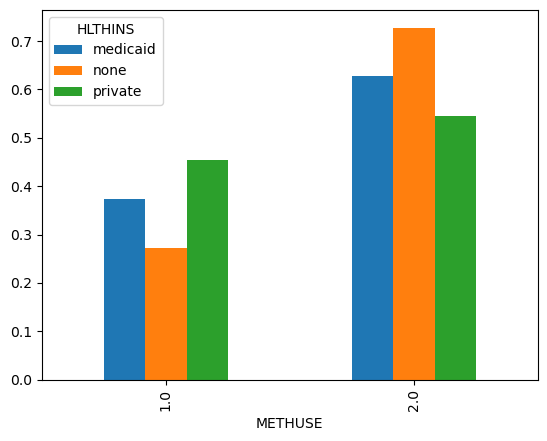

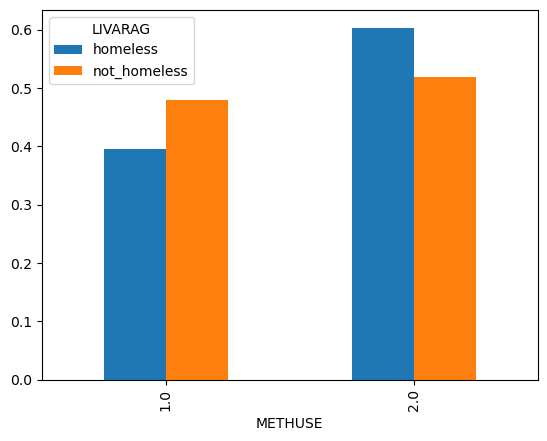

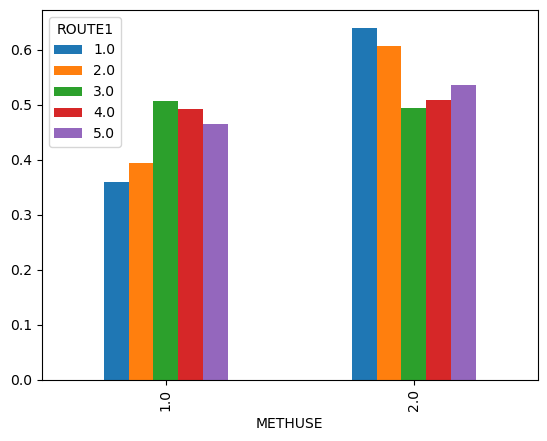

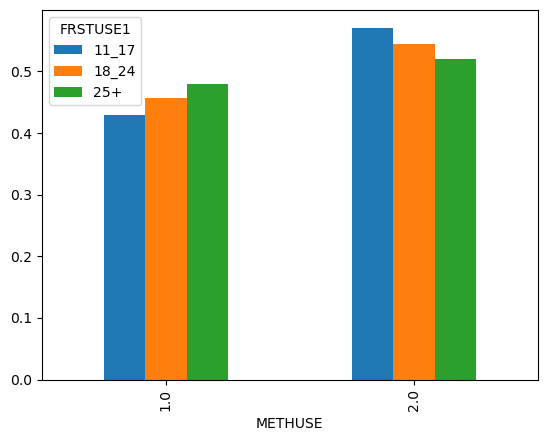

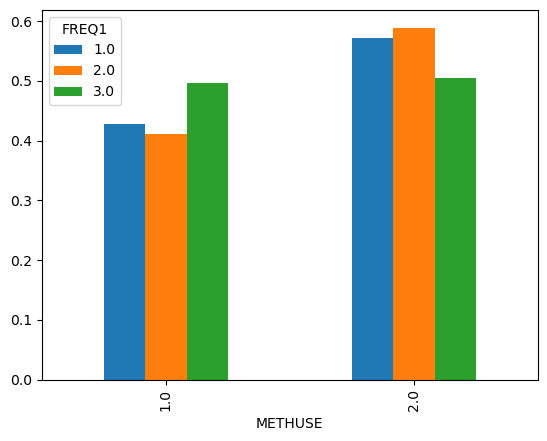

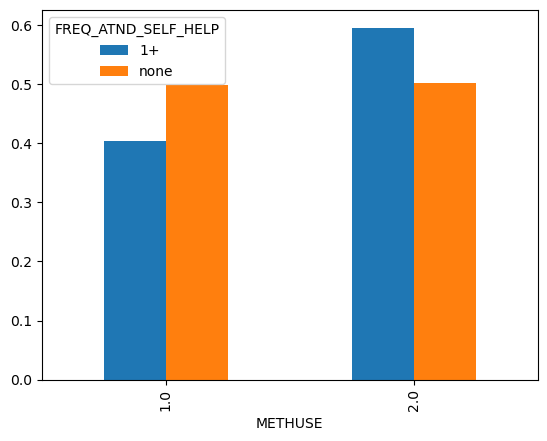

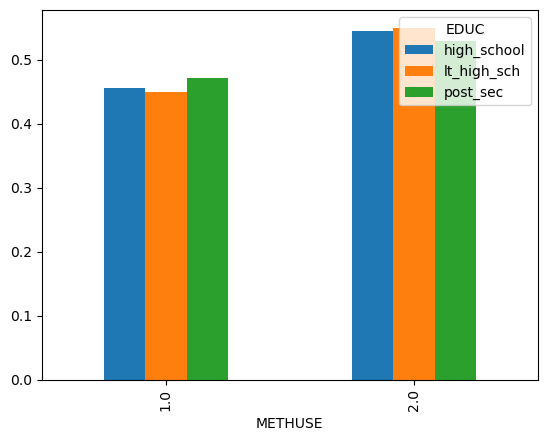

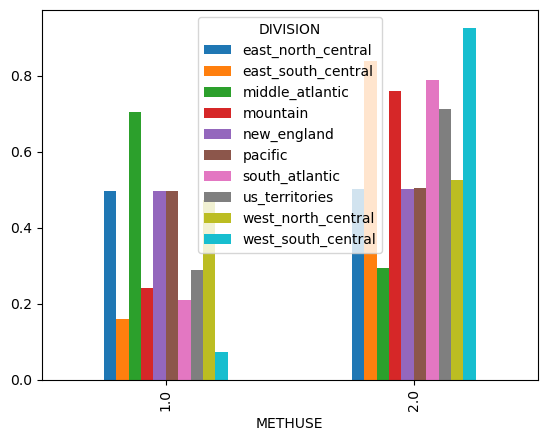

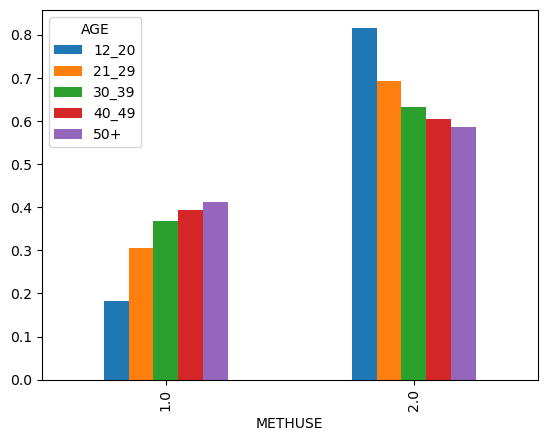

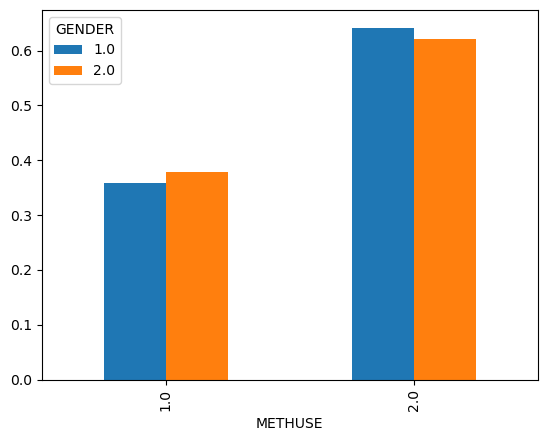

In [69]:
# iterate over all variables of interest to generate a crosstab and graph the cross tab
variables = ['RACE', 'ETHNIC', 'HLTHINS', 'LIVARAG', 'ROUTE1', 'FRSTUSE1', 'FREQ1', 'FREQ_ATND_SELF_HELP', 'EDUC', 'DIVISION', 'AGE', 'GENDER']

for variable in variables:
    table = pd.crosstab(dsm_opioids_df3['METHUSE'], dsm_opioids_df3[variable], normalize='columns').round(decimals=3)
    table.plot.bar()

All of the above variables with the exception of gender, education, and age of first use show some important differences in treatment with methadone/buprenorphine for opioid dependency. We will keep gender in the model anyway as an important modifying factor. 

Therefore the final variables to be entered into the logistic model are the following: `RACE`, `ETHNIC`, `HLTHINS`, `LIVARAG`, `ROUTE1`, `FREQ1`, `FREQ_ATND_SELF_HELP`, `DIVISION`, `AGE`, `GENDER`


**Note 1:** In the third logistical regression model created below (next section), we will be dropping the first dummy variable created per nominal variable to prevent multicollinearity from occurring in the model. 

**Note 2:** Based on the findings above where minimal difference was noticed between the first two models (keeping and dropping NA values), we will drop the NA values to create a 'cleaned' dataset to work from. It is worth noting, however, that this does significantly reduce the size of our dataset, but due to the aforementioned reason and because of time constraints, NA values in the dataframe will be dropped.  

----------------------------------
## CLEANED DATASET AND FINAL LOGISTICAL REGRESSION MODEL

In [70]:
columns_to_keep = ['MARSTAT',
                   'EMPLOY',
                   'METHUSE',
                   'PSYPROB',
                   'GENDER',
                   'VET',
                   'DSMCRIT',
                   'SUB1',
                   'ROUTE1',
                   'FREQ1',
                   'HERFLG',
                   'METHFLG',
                   'OPSYNFLG',
                   'DIVISION',
                   'REGION',
                   'ALCDRUG',
                   'OPIOIDS_FLG',
                   'NON_OPIOID_DRUGS_FLG',
                   'age_12_20',
                   'age_21_29',
                   'age_30_39',
                   'age_40_49',
                   'age_50+',
                   'race_asian',
                   'race_black',
                   'race_indig_island',
                   'race_other',
                   'race_white',
                   'ethnic_latino',
                   'ethnic_non-latino',
                   'educ_high_school',
                   'educ_lt_high_sch',
                   'educ_post_sec',
                   'livarag_homeless',
                   'livarag_not_homeless',
                   'arrests_1+',
                   'arrests_none',
                   'services_ambulatory',
                   'services_detox',
                   'services_rehab',
                   'psource_care_provider',
                   'psource_court',
                   'psource_individual',
                   'psource_sch_work_comm',
                   'noprior_2+',
                   'noprior_none',
                   'noprior_one',
                   'frstuse1_11_17',
                   'frstuse1_18_24',
                   'frstuse1_25+',
                   'hlthins_medicaid',
                   'hlthins_none',
                   'hlthins_private',
                   'self_help_1+',
                   'self_help_none',
                   'division_east_north_central',
                   'division_east_south_central',
                   'division_middle_atlantic',
                   'division_mountain',
                   'division_new_england',
                   'division_pacific',
                   'division_south_atlantic',
                   'division_us_territories',
                   'division_west_north_central',
                   'division_west_south_central',
                  ]
dsm_opioids_cleaned_df = dsm_opioids_df3[columns_to_keep]
dsm_opioids_cleaned_df = dsm_opioids_cleaned_df.dropna()
dsm_opioids_cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 162352 entries, 2 to 1498015
Data columns (total 65 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   MARSTAT                      162352 non-null  float64
 1   EMPLOY                       162352 non-null  float64
 2   METHUSE                      162352 non-null  float64
 3   PSYPROB                      162352 non-null  float64
 4   GENDER                       162352 non-null  float64
 5   VET                          162352 non-null  float64
 6   DSMCRIT                      162352 non-null  float64
 7   SUB1                         162352 non-null  float64
 8   ROUTE1                       162352 non-null  float64
 9   FREQ1                        162352 non-null  float64
 10  HERFLG                       162352 non-null  int64  
 11  METHFLG                      162352 non-null  int64  
 12  OPSYNFLG                     162352 non-null  int64  
 13  DIV

In [71]:
#Using model 2 and 3 as well as above charting of important variables as a guide for model building:

cols = ['age_12_20', #age_30_39 = 1st
        'age_21_29',
        'age_40_49',
        'age_50+',
        'GENDER',
        'EMPLOY',
        'FREQ1',
        'livarag_homeless', #livarag_not_homeless = 1st
        'NON_OPIOID_DRUGS_FLG',
        'psource_court', #psource_individual = 1st
        'psource_care_provider',
        'psource_sch_work_comm',
        'race_black', #race_white = 1st
        'race_indig_island',
        'race_other',
        'race_asian',
        'ethnic_latino', #ethnic_non-latino = 1st
        'hlthins_none', #hlthins_medicaid = 1st
        'hlthins_private',
        'ROUTE1',
        'self_help_1+', #self_help_none = 1st
        'division_east_north_central', #division_us_territories = 1st
        'division_east_south_central',
        'division_middle_atlantic',
        'division_mountain',
        'division_new_england',
        'division_pacific',
        'division_south_atlantic',
        'division_west_north_central',
        'division_west_south_central',
        #'frstuse1_18_24', #frstuse1_11_17 = 1st #Made no major difference to R2
        #'frstuse1_25+', #Made no major difference to R2
        #'PSYPROB', #Made no major difference to R2
        #'VET', #Made little difference to R2 and affected race p-values
        'arrests_1+', #arrests_none = 1st #Made no major difference to R2, but sorts out issues with race and ethinicity
        #'noprior_one', #noprior_none = 1st #Made no major difference to R2
        #'noprior_2+', #Made no major difference to R2
     ]

y = (dsm_opioids_cleaned_df['METHUSE']==1).astype(int) #Recode to yes=1 (no change) and no=0 from no=2
X = dsm_opioids_cleaned_df[cols] #pd.concat([dsm_opioids_df3[nominal_used_cols], dsm_opioids_df3[cols]], axis=1) 

X = X.drop(columns=['ethnic_latino',
                    'EMPLOY',
                   ])

#Create and fit the model
model3 = Logit(y, X)
model3 = model3.fit(method='newton', maxiter=500)
model3.summary2()

Optimization terminated successfully.
         Current function value: 0.519666
         Iterations 7


<class 'statsmodels.iolib.summary2.Summary'>
"""
                               Results: Logit
============================================================================
Model:                  Logit               Method:              MLE        
Dependent Variable:     METHUSE             Pseudo R-squared:    0.250      
Date:                   2025-04-14 12:56    AIC:                 168795.6843
No. Observations:       162352              BIC:                 169085.6125
Df Model:               28                  Log-Likelihood:      -84369.    
Df Residuals:           162323              LL-Null:             -1.1253e+05
Converged:              1.0000              LLR p-value:         0.0000     
No. Iterations:         7.0000              Scale:               1.0000     
----------------------------------------------------------------------------
                             Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
----------------------------------------------------------------------------
age_12_20                   -1.2713   0.0548 -23.2133 0.0000 -1.3786 -1.1639
age_21_29                   -0.3345   0.0164 -20.4132 0.0000 -0.3666 -0.3024
age_40_49                    0.1154   0.0160   7.2257 0.0000  0.0841  0.1468
age_50+                      0.2019   0.0181  11.1284 0.0000  0.1664  0.2375
GENDER                       0.1096   0.0123   8.9292 0.0000  0.0855  0.1336
FREQ1                        0.0352   0.0070   5.0541 0.0000  0.0215  0.0488
livarag_homeless            -0.3736   0.0172 -21.6869 0.0000 -0.4073 -0.3398
NON_OPIOID_DRUGS_FLG        -0.4276   0.0128 -33.4098 0.0000 -0.4527 -0.4025
psource_court               -1.2600   0.0184 -68.3235 0.0000 -1.2962 -1.2239
psource_care_provider       -0.7351   0.0181 -40.7076 0.0000 -0.7705 -0.6997
psource_sch_work_comm       -0.7807   0.0244 -31.9871 0.0000 -0.8286 -0.7329
race_black                  -0.1613   0.0183  -8.8159 0.0000 -0.1971 -0.1254
race_indig_island           -0.2308   0.0531  -4.3460 0.0000 -0.3348 -0.1267
race_other                  -0.3567   0.0226 -15.7583 0.0000 -0.4011 -0.3124
race_asian                  -0.3540   0.0994  -3.5603 0.0004 -0.5489 -0.1591
hlthins_none                -0.6998   0.0208 -33.7189 0.0000 -0.7404 -0.6591
hlthins_private             -0.3610   0.0339 -10.6615 0.0000 -0.4273 -0.2946
ROUTE1                       0.1185   0.0054  22.0713 0.0000  0.1080  0.1290
self_help_1+                -0.3136   0.0157 -19.9667 0.0000 -0.3444 -0.2828
division_east_north_central  0.2910   0.0317   9.1786 0.0000  0.2288  0.3531
division_east_south_central -1.1192   0.0414 -27.0426 0.0000 -1.2003 -1.0380
division_middle_atlantic     1.9822   0.0328  60.4699 0.0000  1.9180  2.0464
division_mountain            0.7020   0.0350  20.0439 0.0000  0.6333  0.7706
division_new_england         0.3025   0.0323   9.3604 0.0000  0.2392  0.3659
division_pacific             0.4684   0.0847   5.5302 0.0000  0.3024  0.6344
division_south_atlantic     -1.1745   0.0314 -37.3557 0.0000 -1.2361 -1.1129
division_west_north_central  0.6339   0.0466  13.5900 0.0000  0.5425  0.7253
division_west_south_central -2.4279   0.0726 -33.4239 0.0000 -2.5702 -2.2855
arrests_1+                  -0.1333   0.0265  -5.0368 0.0000 -0.1852 -0.0814
============================================================================

"""

In [72]:
correlation_matrix = dsm_opioids_cleaned_df.corr(numeric_only=True)

threshold = 0.6
# Get upper triangle of the correlation matrix
upper = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Get pairs with correlation above threshold
high_corr_pairs = upper.stack()[abs(upper.stack()) > threshold]
print(high_corr_pairs)
#NOTE THAT THE STRONG CORRELATION BETWEEN BLACK AND WHITE RACE MIGHT NEED TO BE CHECKED OUT

HERFLG               OPSYNFLG                   -0.788701
REGION               division_middle_atlantic   -0.657910
race_black           race_white                 -0.679381
ethnic_latino        ethnic_non-latino          -0.953008
livarag_homeless     livarag_not_homeless       -0.880732
services_ambulatory  services_rehab             -0.725032
noprior_2+           noprior_none               -0.604552
self_help_1+         self_help_none             -0.884712
dtype: float64


We will now generate the odds ratios by exponentiating the coefficients for each of the parameters in the final model and will explain the results.

In [73]:
# create table with parameters and odds ratios and 95% CIs
params = model3.params
conf = model3.conf_int()

odds_ratios = np.exp(params)
conf_odds = np.exp(conf)

result_table = pd.DataFrame({
    'name': params.index,
    'coef': params.values,
    'odds ratio': odds_ratios.values.round(decimals=2),
    'OR lower CI': conf_odds[0].values.round(decimals=2),
    'OR upper CI': conf_odds[1].values.round(decimals=2)
})

result_table

,name,coef,odds ratio,OR lower CI,OR upper CI
0,age_12_20,-1.271283,0.28,0.25,0.31
1,age_21_29,-0.334522,0.72,0.69,0.74
2,age_40_49,0.115444,1.12,1.09,1.16
3,age_50+,0.201948,1.22,1.18,1.27
4,GENDER,0.109580,1.12,1.09,1.14
5,FREQ1,0.035200,1.04,1.02,1.05
6,livarag_homeless,-0.373575,0.69,0.67,0.71
7,NON_OPIOID_DRUGS_FLG,-0.427567,0.65,0.64,0.67
8,psource_court,-1.260024,0.28,0.27,0.29
9,psource_care_provider,-0.735139,0.48,0.46,0.50


# YAY RESULTS!
